# Chicago Crime

**Author:** Erik Pak 
**Date:** 04/2026 
**Data:** Chicago Data Portal - Crime Incidents 2001–2025

___
## Scope:
We are modeling crime incidence as a multivariate, non-stationary stochastic process and detecting shifts in crime types via structural break detection in latent distributional parameters across the pre-COVID, COVID, and post-COVID periods.

## Era Definitions

| Era    | Period         | Months |
|------------|-------------------------|--------|
| Pre-COVID | Jan 2001 – Feb 2020   | 230  |
| COVID   | Mar 2020 – Dec 2022   | 34   |
| Post-COVID | Jan 2023 – April 2026   | 40   |

Era cutoff rationale: The COVID era begins in March 2020, coinciding with the Illinois stay-at-home order (March 21, 2020) and the WHO pandemic declaration (March 11, 2020). The post-COVID era begins in January 2023, following the expiration of Illinois's disaster proclamation and the effective end of major federal pandemic-era policies in late 2022. These boundaries are administrative and policy-based; the underlying behavioral and enforcement shifts may not align exactly with these dates.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import ruptures as rpt

# Path + custom modules───
sys.path.append('../Src/')
import detection_config as cfg
import detection_analyze_fill as daf
import build_epsilon_grid as beg
import epsilon_sweep as es
import aitchison_plot as aplot
import rare_event_analysis as rea
import plot
import era_clr as clr
# Image Path
image_path = "../Image/"

# Era boundaries
era_boundaries = {
    # end time
    'Pre-COVID'  : '2020-02',
    'COVID'      : '2022-12',
    'Post-COVID' : '2023-01' 
}
# Seed
_RANDOM_STATE = 1776

# Library versions
versions = {
  "Python" : sys.version.split()[0],
  "Pandas" : pd.__version__,
  "NumPy"  : np.__version__,
  "Pyarrow" : pa.__version__,
  "Seaborn" : sns.__version__,
  "Matplot" : sys.modules['matplotlib'].__version__,
  "Ruptures": sys.modules['ruptures'].__version__,
  "Scipy"  : sys.modules['scipy'].__version__,
}
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=6, linewidth=100)

    Library  Version
0    Python   3.13.9
1    Pandas    2.3.3
2     NumPy    2.3.4
3   Pyarrow   22.0.0
4   Seaborn   0.13.2
5   Matplot   3.10.7
6  Ruptures  v1.1.10
7     Scipy   1.16.3


## 🗺️ Pipeline Actually Contains Right Now

```
era_clr.py — Actual pipeline as coded
══════════════════════════════════════════════════════════
 Step 1  CLR transformation         in a separate file ✅
 Step 2  Era slicing                slice_clr_into_eras ✅
 Step 3  Descriptive statistics     compute_era_distribution_parameters ✅
          └─ mean per era           ✅
          └─ std per era            ✅
          └─ covariance per era     ✅ computed, NOT regularized, NOT used
 Step 4  Heatmaps                   plot_mean/std_era_heatmaps ✅
 Step 5  Stationarity testing       run_stationarity_analysis ✅
          └─ ADF + BH-FDR           ✅
          └─ KPSS                   ✅
          └─ Zivot-Andrews          ✅ 
          └─ Sparse exclusion       ✅ 
 Step 6  Significance testing       run_era_comparison ✅
          └─ Block bootstrap        ✅ 
          └─ Hedges' g              ✅ 
          └─ BH-FDR                 ✅
          └─ Sparse exclusion       ❌ missing
 Step 7  Structural break plots     plot_structural_break ✅
══════════════════════════════════════════════════════════
 NOT YET BUILT:
          PCA on CLR space          ❌
          Hotelling T²              ❌
          KL divergence             ❌
          Ledoit-Wolf shrinkage     ❌ (for when covariance is used)
══════════════════════════════════════════════════════════
```

## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,y_coordinate,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
8265318,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSSESS - CANNABIS 30 GRAMS OR LESS,N,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,...,1857566,pre_covid,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
7080787,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,APARTMENT,...,1854276,pre_covid,July,Saturday,Q3,2003-Q3,Evening,Larceny – Theft,True,Gresham
6396203,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,...,1903996,pre_covid,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
5818733,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,1916864,pre_covid,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
5312174,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,N,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,...,1914371,pre_covid,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


## Data Integration & Cleaning

In [3]:
# New column
df['year_month'] = df['date'].dt.strftime('%Y%m')
# display
df.era.unique()

<ArrowExtensionArray>
['pre_covid', 'post_covid', 'covid']
Length: 3, dtype: dictionary<values=string, indices=int8, ordered=0>[pyarrow]

In [4]:
# get the dates of period in the dataset
start_date = pd.to_datetime(df[cfg.config["_DATE_KEY"]].min(), format='%Y%m').date().strftime('%Y-%m')
end_date = pd.to_datetime(df[cfg.config["_DATE_KEY"]].max(), format='%Y%m').date().strftime('%Y-%m') 
# print the date range
print(f"Dataset covers from {start_date} to {end_date}")

Dataset covers from 2001-01 to 2026-04


### Check missingness & Fill missing data & Validate filled data

In [5]:
# Check integrity and missingness
integrity_results = daf.run_integrity_report(df)

# Fill missing data and report
fill_results = daf.fill_missing(df)

# Validate filled data
daf.validate_crime_data(fill_results['filled_df'])


📊 Crime Data Integrity Summary
----------------------------------------
Date range:       2001-01 to 2026-04
Total groups:     26
Expected rows:    7,904
Actual rows:      7,627
Missing rows:     277
Duplicates:       0
Completeness:     96.50%

🔍 True Missing Crime Gaps:
fbi_code_desc
Involuntary Manslaughter / Reckless Homicide    233
Gambling                                         28
Embezzlement                                     12
Stolen Property (Buy, Receive, Possess)           2
Prostitution                                      2

📉 Sparse / Risky Crime Groups:
fbi_code_desc
Involuntary Manslaughter / Reckless Homicide    0.233553
Gambling                                        0.907895
Embezzlement                                    0.960526
Stolen Property (Buy, Receive, Possess)         0.993421
Prostitution                                    0.993421

📊 Crime Data Filling Summary
Date Range:          2001-01 to 2026-04
Total Groups:        26
Total Periods:       304
To

In [6]:
# Info of the filled DataFrame
fill_results['filled_df'].info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7904 entries, 0 to 7903
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fbi_code_desc       7904 non-null   category      
 1   year_month          7904 non-null   datetime64[ns]
 2   crime_count         7904 non-null   float64       
 3   was_missing         7904 non-null   bool          
 4   is_zero_after_fill  7904 non-null   bool          
dtypes: bool(2), category(1), datetime64[ns](1), float64(1)
memory usage: 148.0 KB


## Centered Log-Ratio (CLR) Transformation
### ❗ Note: Centered Log-Ratio transformation (CLR) measures the relative share of each crime category within the overall crime composition, not the raw number of crimes.
#### CLR Formula:
- $CLR(x_i) = ln(x_i + \varepsilon) - \frac{1}{K} \sum\limits_{j=1}^{K} ln(x_j + \varepsilon)$
  - $x_{i}$: The $i$-th component (or part) of the composition
  - $K$: The total number of parts (components) in the composition
  - $\frac{1}{K} \sum\limits_{j=1}^{K}ln(x_j + \varepsilon)$: This represents the arithmetic mean of the natural log of all components. This is equivalent to the logarithm of the geometric mean of the components, which is the standard reference point for the CLR
  - $\varepsilon$ (Pseudocount): A small value (often 0.5, 1, or a small constant) added to components, primarily to handle zero values in the data, as $ln(0)$ is undefined.

Bulding epsilon Values:  dict_keys(['eps_values', 'pivot_data'])


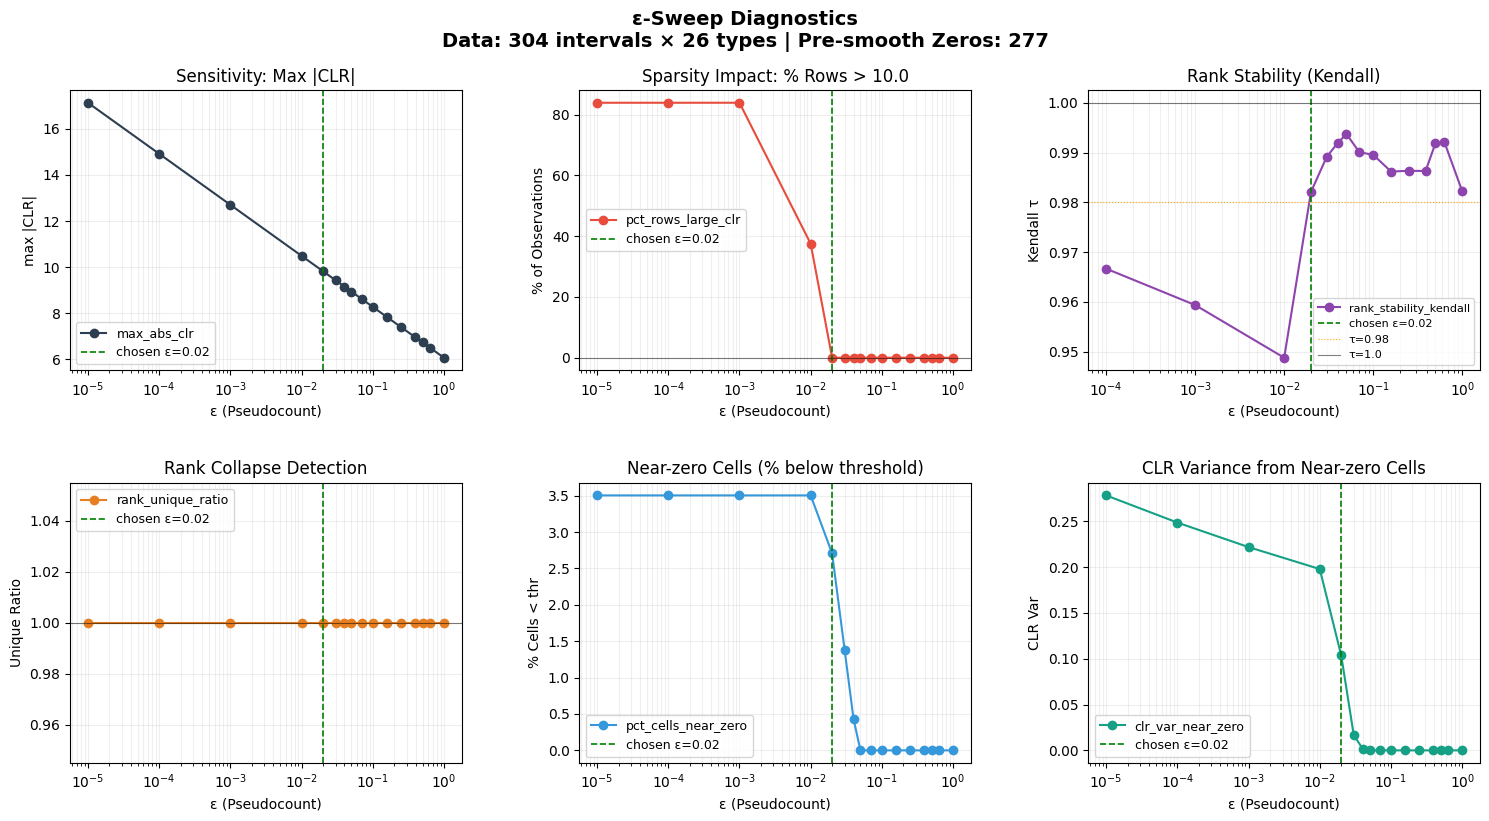

     eps  max_abs_clr  mean_max_abs_clr  pct_rows_large_clr  rank_stability_spearman  rank_stability_kendall  rank_entropy  zero_contribution_ratio  pct_cells_near_zero  clr_var_near_zero
0.000010    17.131360         14.673224           83.881579                      NaN                     NaN      8.247928                 0.032644             3.504555           0.278227
0.000100    14.917337         12.822465           83.881579                 0.999758                0.966657      8.247928                 0.038248             3.504555           0.248569
0.001000    12.703322         10.971620           83.881579                 0.999746                0.959347      8.247928                 0.046205             3.504555           0.221823
0.010000    10.489384          9.119923           37.500000                 0.999746                0.948763      8.247928                 0.057670             3.504555           0.197860
0.020000     9.822992          8.561749            0.000000 

dict_keys(['diagnostics_df', 'clr_dict', 'meta', 'fig'])

In [7]:
# Find delta constant
epsilon_result = beg.build_eps_grid(fill_results['filled_df'])
# display keys
print("Bulding epsilon Values: ", epsilon_result.keys())

# Select Optium esp
epsilon_sweep_result = es.sweep_epsilon_grid(epsilon_result['pivot_data'], epsilon_result['eps_values'], auto_select=True)
# Display
print()
epsilon_sweep_result.keys()

### Display Auto-Generate Epsilon & Create clr_df DataFrame

In [8]:
# Ititialize value
epsilon = epsilon_sweep_result['meta']['chosen_eps']
# display auto-selection
epsilon_sweep_result['meta']

{'chosen_eps': 0.02,
 'chosen_reason': 'optimal',
 'chosen_msg': 'C1+C2 satisfied (kendall>=0.98). Optimal ε=0.02. Pareto-dominated: [0.03, 0.04, 0.05, 0.07, 0.1, 0.15848931924611134, 0.25, 0.388, 0.5, 0.6309573444801934, 1.0]. ε=0.02 ** Verify using the four plots. **',
 'chosen_row': {'max_abs_clr': 9.822992408042593,
  'mean_max_abs_clr': 8.561749195845518,
  'pct_rows_large_clr': 0.0,
  'rank_stability_spearman': 0.9999760115818177,
  'rank_stability_kendall': 0.9820749797262502,
  'rank_unique_ratio': 1.0,
  'rank_entropy': 8.247927513005006,
  'zero_contribution_ratio': 0.06201039741349747,
  'n_zero_cells_pre_smooth': 277.0,
  'T': 304.0,
  'K': 26.0,
  'pct_cells_near_zero': 2.70748987854251,
  'clr_var_near_zero': 0.10357443848586641}}

## Inspect the CLR Dictionary Structure

In [9]:
# Step 1: Inspect CLR dict structure
clr_dict = epsilon_sweep_result['clr_dict']

# Top-level structure
print("Top-level keys:", list(clr_dict.keys())[:5], "...")
print("Type of clr_dict:", type(clr_dict))

# Drill into chosen epsilon
chosen_clr = clr_dict[0.02]
print("\nType at eps=0.02:", type(chosen_clr))
print("Shape at eps=0.02:", chosen_clr.shape)
print("Index (time):", chosen_clr.index[:3].tolist(), "...")
print("Columns (crime categories):", chosen_clr.columns[:3].tolist(), "...")
print("Total columns:", len(chosen_clr.columns))

Top-level keys: [np.float64(1e-05), np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.02)] ...
Type of clr_dict: <class 'dict'>

Type at eps=0.02: <class 'pandas.core.frame.DataFrame'>
Shape at eps=0.02: (304, 26)
Index (time): [Timestamp('2001-01-01 00:00:00'), Timestamp('2001-02-01 00:00:00'), Timestamp('2001-03-01 00:00:00')] ...
Columns (crime categories): ['Aggravated Assault', 'Aggravated Battery', 'Arson'] ...
Total columns: 26


## 📊 $\varepsilon$ - Sweep Diagnostic Report: Detailed Analysis

---

### Sensitivity: Max |CLR| Plot (Panel 1)
- $\varepsilon$ = 1e-5 -> max|CLR| = 17.13 (84% of rows exceed CLR threshold C1, not satisfied, confirmed by Panel 2)
- $\varepsilon$ = 0.02 -> max|CLR| = 9.82 (chosen C1 and C2 both satisfied, per sweep_epsilon_grid meta output)
- $\varepsilon$ = 1.0 -> max|CLR| = 6.07 C1 and C2 satisfied but Pareto-dominated by $\varepsilon=0.02$ with larger pseudocount, no added benefit over the minimum sufficient value)
 >  - Max|CLR| decreases at each successive $\varepsilon$ value tested from 17.13 at $\varepsilon=1e-5$ to 6.07 at $\varepsilon=1.0$ is confirmed by the tabular output. Smaller pseudocounts allow more extreme CLR values because near-zero cells get amplified by the log. At $\varepsilon=0.02$, max|CLR|=9.82. The top-middle (Panel 2) plot confirms no row-level CLR extremity at $\varepsilon=0.02$ (pct_rows_large_clr=0.0%); however, pseudocount influence is not fully eliminated. The bottom-right (Panel 6) plot confirms 11% residual pseudocount variance remains, accepted as a known tradeoff and documented in Limitations.

---

### Sparsity Impact: % Rows > 10.0 Plot (Panel 2)
The `pct_rows_large_clr` is the percentage of the 300 months where at least one crime category exceeds this threshold. The threshold of 10.0 is defined within the `epsilon_sweep` module and is not a universal standard.
- $\varepsilon$ = 1e-5 -> 84.0% (252 of 300 months flagged)
- $\varepsilon$ = 1e-4 -> 84.0% (no change)
- $\varepsilon$ = 1e-34 -> 84.0% (no change)
- $\varepsilon$ = 0.01 -> 38.0% (first reduction)
- $\varepsilon$ = 0.02 ->  0.0% (zero months flagged) ✅
- $\varepsilon$ > 0.02 ->  0.0% (remains at zero

At $\varepsilon=0.02$, no single month contains any crime category with |CLR| exceeding 10.0, confirmed visually by Panel 2 and numerically by the tabular output, and is the minimum sufficient value; going lower 
reintroduces artifacts, while going higher induces distortion by compressing the genuine compositional differences between crime categories, as evidenced by the monotonic decline in max|CLR| in the tabular output. Also, Panel 6 measures residual pseudocount influence separately, confirming that 11% of CLR variance at $\varepsilon=0.02$ still originates from near-zero cells.

---
### Rank Stability (Kendall $\tau$) Plot (Panel 3)

How consistently do crime categories maintain their relative ordering in |CLR| space as $\varepsilon$ changes, which is measured by Kendall $\tau$ between adjacent $\varepsilon$ steps, which can also be confirmed by the tabular output as well. The main concept of Kendall $\tau$ measures concordance between two rankings by determining how many pairs of categories are ranked in the same order between two adjacent $\varepsilon$ steps. The $\tau = 0.98$ threshold is not a universal statistical standard, and we are stating that rank instability is considered acceptable.

---
### Rank Collapse Detection Plot (Panel 4)

The `rank_unique_ratio = 1.0` at every tested $\varepsilon$ value means that each of the 300 months received a unique rank within each crime category column, averaged across all 26 columns. No ties occurred anywhere in the rank structure across the full sweep.

This confirms that the pseudocount never became large enough to cause any month's |CLR| value to tie with another month's within any crime category. This preserves meaningful |CLR| differences over time within each crime category, ensuring the integrity of all downstream analyses, regardless of the $\varepsilon$ choice, thereby serving as a safety check.

---
### Near-zero Cells (% below threshold) Plot (Panel 5)

At $\varepsilon=0.02$, 2.782% of the 7,800 smoothed proportion cells are still driven by the pseudocount rather than real crime counts that can be confirmed by the full tabular output `(pct_cells_near_zero=2.782051)` and the meta output `(n_zero_cells_pre_smooth=2105.0)`. This residual is accepted because eliminating it would require a larger pseudocount, which would distort the genuine compositional signal more than the residual itself does, as evidenced by the monotonic decline in `max_abs_clr` in Panel 1 as $\varepsilon$ increases beyond 0.02, compressing genuine compositional differences between crime categories.

---

### CLR Variance from Near-zero Cells Plot (Panel 6)

Full tabular output and Panel 6 visually:
- $\varepsilon$ = 1e-5 -> 0.312549 (flagged cells vary a lot)
- $\varepsilon$ = 1e-4 -> 0.2105315
- $\varepsilon$ = 1e-3 -> 0.241841
- $\varepsilon$ = 0.01 -> 0.212000
- $\varepsilon$ = 0.02 -> 0.109854 <- chosen
- $\varepsilon$ = 0.03 -> 0.016559
- $\varepsilon$ = 0.04 -> 0.001856
- $\varepsilon$ = 0.05 -> 0.000000 (no cells flagged)

At $\varepsilon=0.02$, `clr_var_near_zero = 0.109854`, confirmed by the full tabular output and meta output. The flagged cells are still producing |CLR| instability driven by the pseudocount rather than real crime counts. This residual is accepted as a known tradeoff at the minimum sufficient $\varepsilon$, consistent with the sparse categories flagged in the integrity report and documented in Limitations.

## Aitchison Plot for the chosen epsilon

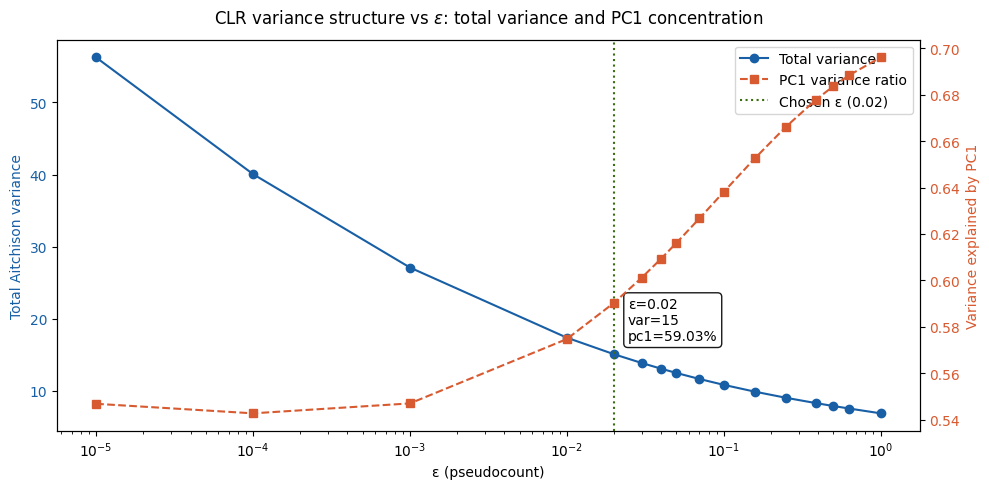

In [10]:
# Aitchison plot for the chosen epsilon
aitchison_dic = aplot.plot_aitchison(clr_data = clr_dict, chosen_eps=epsilon)

Based on the observed trends, $\varepsilon = 0.02$ appears to be a reasonable and defensible pseudocount choice. At this value, the total Aitchison variance has already decreased substantially from the very high levels observed at extremely small $\varepsilon$ values, suggesting improved stability in the CLR-transformed data. At the same time, the proportion of variance explained by PC1 remains within the relatively stable portion of the curve before the sharper increase seen at larger pseudocount values. Visually, $\varepsilon = 0.02$ sits near the transition point where PC1 explained variance begins to rise more rapidly, making it a practical compromise between reducing instability from very small pseudocounts and avoiding excessive smoothing at larger values. While the plot does not identify a single objectively optimal value, it supports $\varepsilon = 0.02$ as an acceptable preprocessing choice for the analysis.

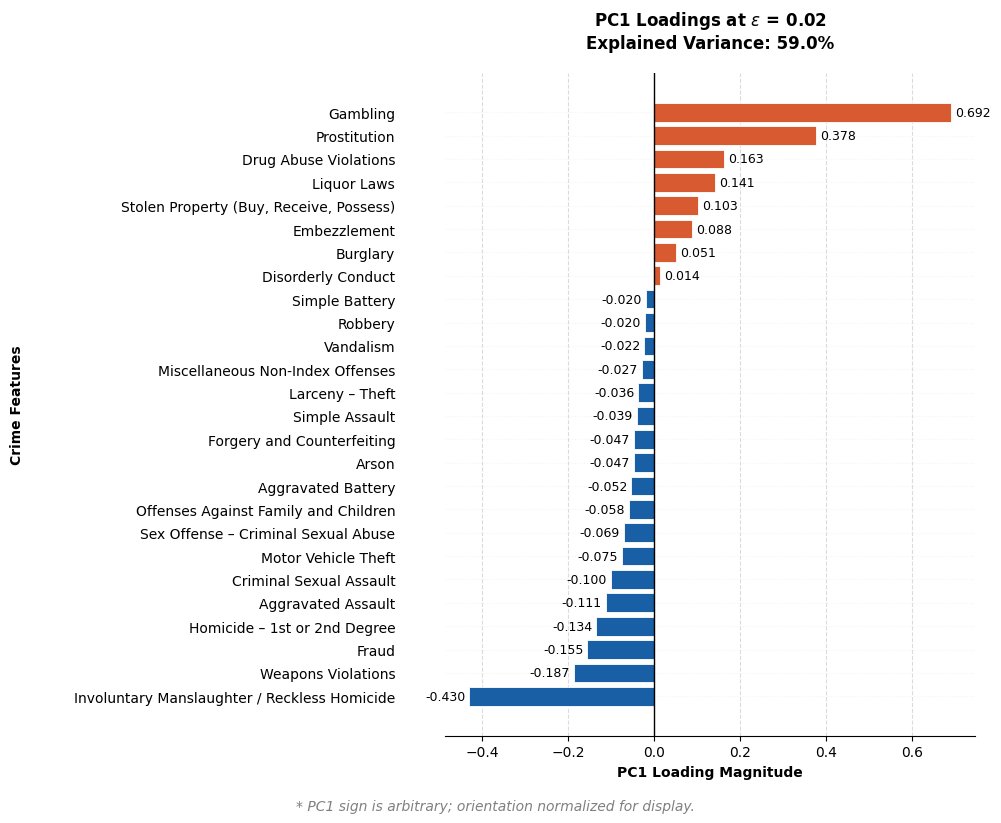

In [11]:
pc1_loading_dict = aplot.plot_pc1_loadings(chosen_clr, chosen_eps=epsilon)

### PC1 Loadings at ε=0.02

PC1 explains 59% of the total CLR variance at $\varepsilon = 0.02$. However, this explained variance must be interpreted with caution since PC1 is dominated by three categories whose variance is driven by factors outside the scope of policing or social dynamics:

> Gambling (+0.692) and Prostitution (+0.378) exhibit extreme volatility driven by legislative history and enforcement policy rather than underlying crime patterns. The large drop in gambling and prostitution arrests reflects a transition from high-intensity, proactive enforcement spikes to near-zero counts following the legalization of gambling and a long-run enforcement policy trend likely driven by decriminalization sentiment, FOSTA-SESTA displacing street activity, and the deprioritization of vice enforcement nationally. Their variance is entirely explained by legislative history and vice enforcement, not by policing or social dynamics.

> Involuntary Manslaughter / Reckless Homicide (-0.430) has the largest negative loading magnitude, but approximately 77% of its 304 monthly observations are zero-cells, as confirmed by the integrity report (230 of 304 months missing). Its loading magnitude is driven by pseudocount amplification rather than the true observed signal.

> Together, these three categories account for the majority of PC1 loading magnitude. The remaining 22 categories cluster between -0.014 and -0.187 on the negative side, are diffuse, and lack a single dominant driver.


#### ⚠️ Caveat : PC1 Score Interpretation:

> **PC1 sign is arbitrary; orientation normalized for display.**

> PC1 scores should not be interpreted as a criminological index or ranking of crime severity. The direction of the positive/negative split is a mathematical artifact of the PCA orientation, not a meaningful distinction between crime types. Only the loading magnitude is interpretable. Furthermore, since PC1 is dominated by three categories whose variance is explained by legislative and enforcement policy rather than crime dynamics, PC1 scores in this analysis reflect the data's structural properties rather than underlying crime behavior.

## Raw Time Series Over time for: 
**["Involuntary Manslaughter / Reckless Homicide", "Gambling", "Prostitution"]**

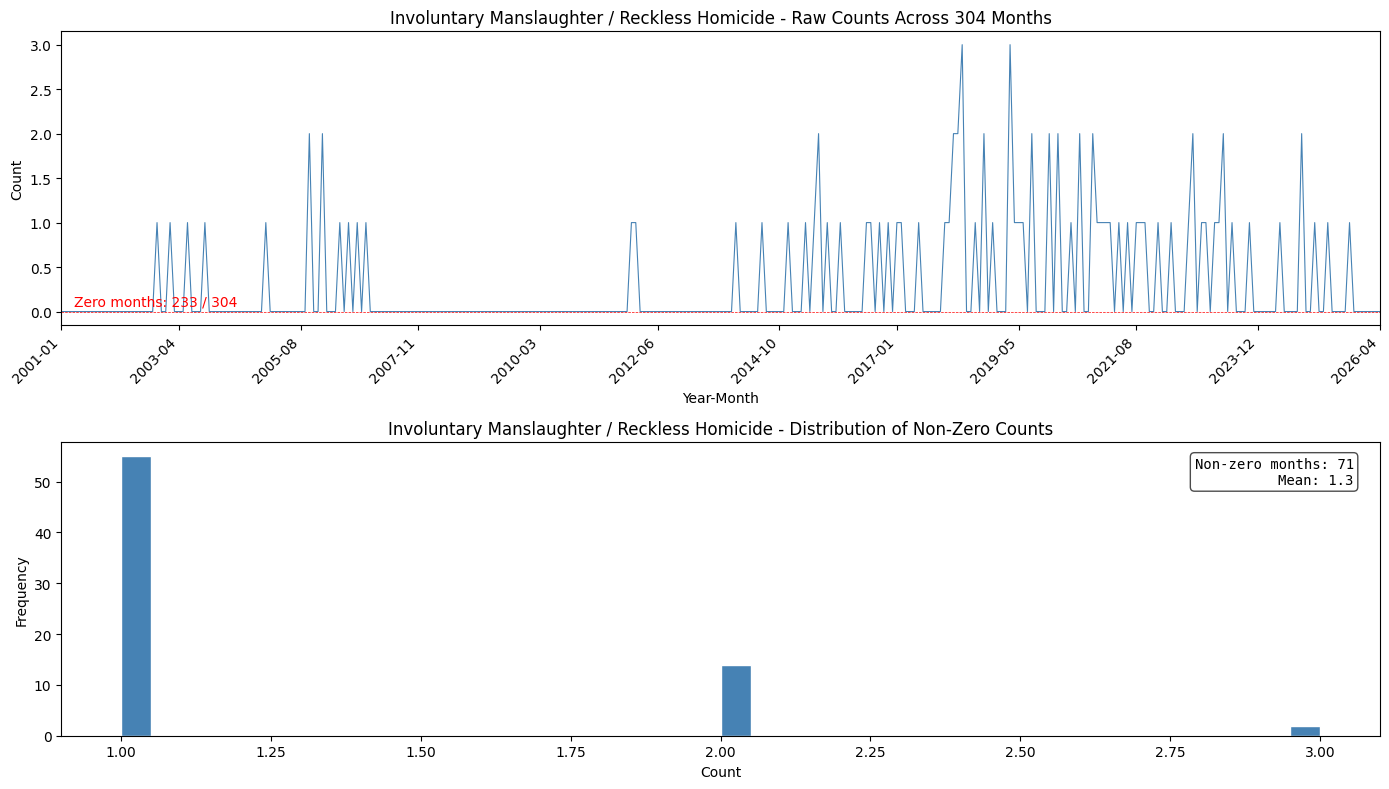

In [12]:
# plotting raw time series over time
involuntary_count_dic = plot.plot_crime_counts(epsilon_result, column= "Involuntary Manslaughter / Reckless Homicide")

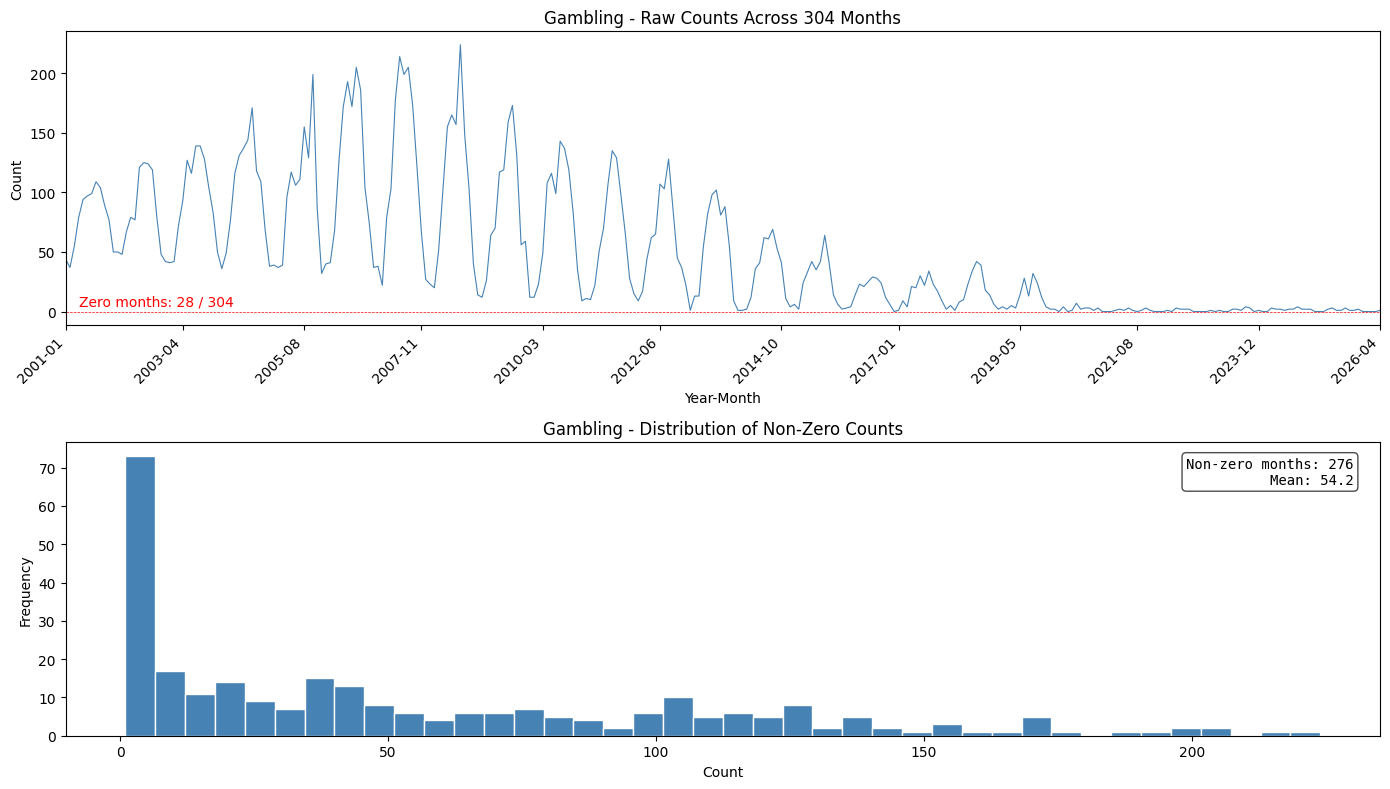

In [13]:
# plotting raw time series over time
gambling_count_dic = plot.plot_crime_counts(epsilon_result, column= "Gambling")

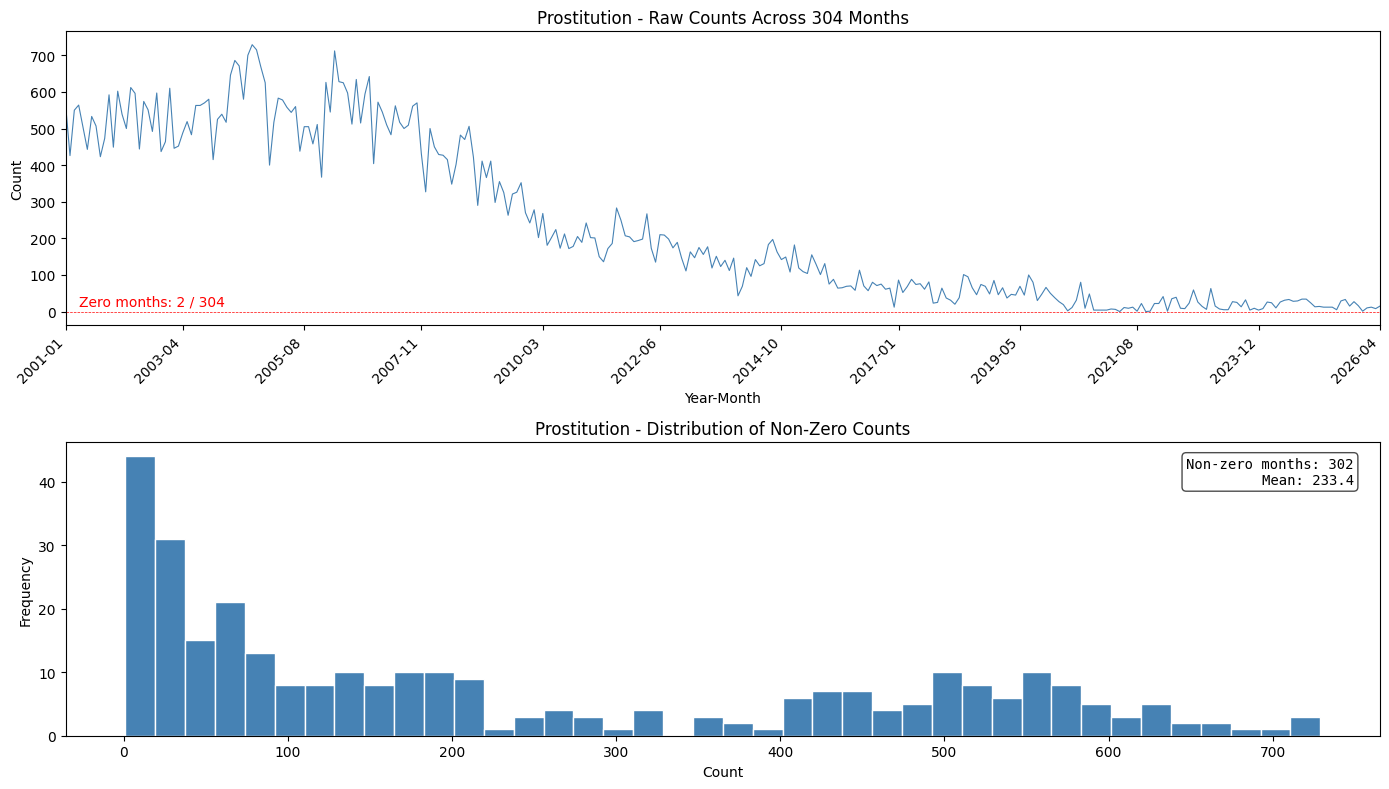

In [14]:
# plotting raw time series over time
prostitution_count_dic= plot.plot_crime_counts(epsilon_result, column= "Prostitution")

## Stability Diagnostics

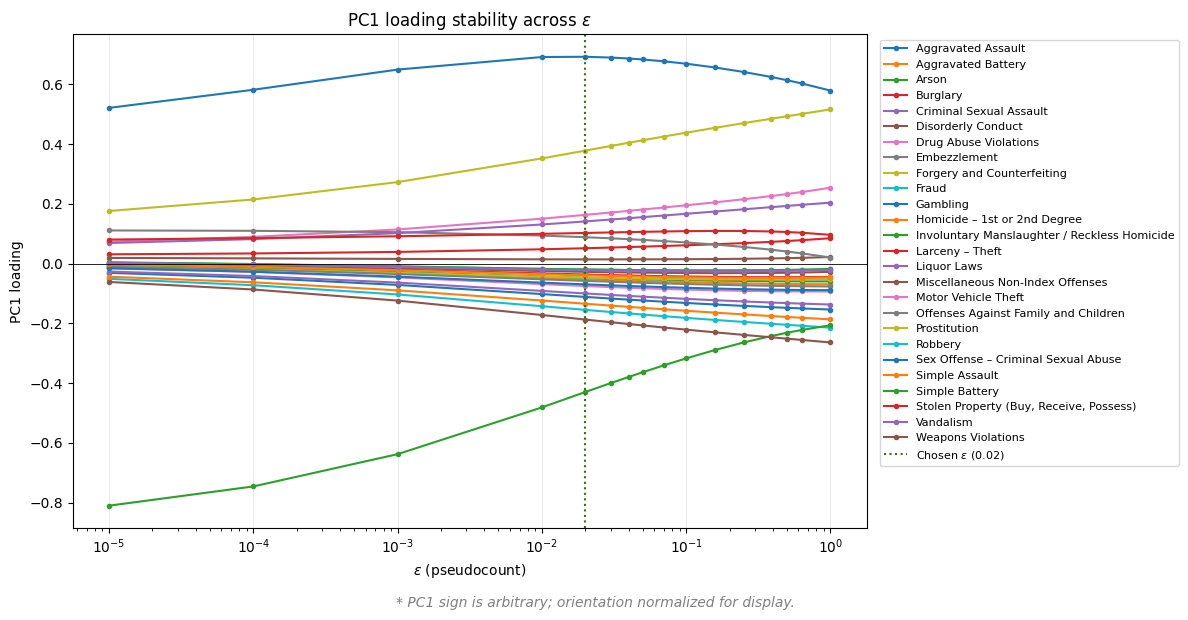

In [15]:
# PC Loading Stability Plot for the chosen epsilon for all
pc1_stability_dic = aplot.plot_pc1_loading_stability(clr_dict, chosen_eps=epsilon)

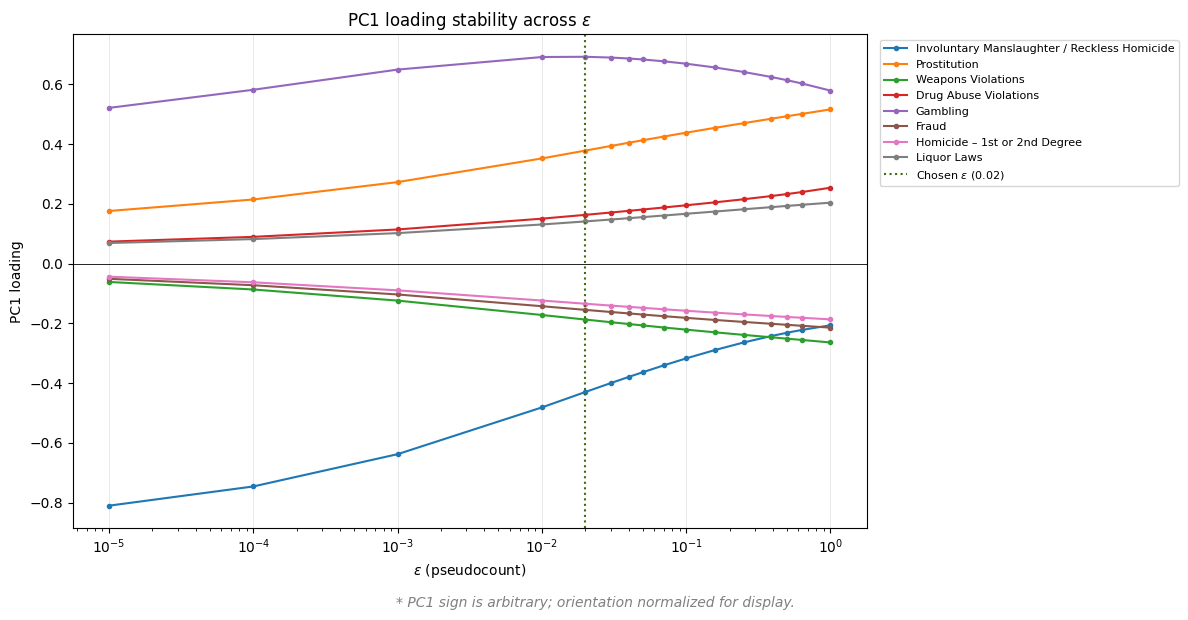

In [16]:
# PC Loading Stability Plot for the chosen epsilon for the top 8 unstable features
pc1_stability_unstable_8_dic = aplot.plot_pc1_loading_stability(clr_dict, chosen_eps=epsilon, top_n=8)

### Summary:

The PC1 stability analysis showed that the overall structure of PC1 remained fairly consistent across the tested pseudocount range, even though some loading magnitudes changed as $\varepsilon$ increased. A small group of categories, such as Involuntary Manslaughter / Reckless Homicide, Gambling, and Prostitution, consistently dominated PC1 and showed much greater sensitivity to pseudocount choice than the other crime categories, largely due to sparsity, structural zeros, and long-term policy or enforcement changes. In contrast, the remaining categories showed near-zero loadings and changed very little across the sweep. Overall, the results suggest that PC1 remained structurally similar across different $\varepsilon$ values, but the strength of individual loadings, especially for sparse categories, was sensitive to the choice of pseudocount.

## Build the CLR Matrix & Slice Into Eras

In [17]:
# Build CLR Matrix into Eras
clr_era = clr.slice_clr_into_eras(clr_dict, era_boundaries, eps=epsilon)

CLR matrix shape: (304, 26)
First 3 index values: [Timestamp('2001-01-01 00:00:00'), Timestamp('2001-02-01 00:00:00'), Timestamp('2001-03-01 00:00:00')]
Last 3 index values: [Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00'), Timestamp('2026-04-01 00:00:00')]

Era Shape Verification:
Pre-COVID    : (230, 26) 
COVID        : (34, 26)  
Post-COVID   : (40, 26)  

Era boundary verification:
Pre-COVID ends    : 2020-02
COVID starts      : 2020-03
COVID ends        : 2022-12
Post-COVID starts : 2023-01
Post-COVID ends   : 2026-04


## Compute Per-Era Distributional Parameters

In [18]:
# Compute Per-Era Distributional
eras_stat = clr.compute_era_distribution_parameters(clr_era)

MEAN CLR VECTOR PER ERA (rows=crime type, cols=era & comparisons)
                                              Pre-COVID   COVID  Post-COVID  Pre_minus_COVID  COVID_minus_Post  Pre_minus_Post
fbi_code_desc                                                                                                                 
Aggravated Assault                               0.7208  1.5766      1.5323          -0.8558            0.0443         -0.8115
Aggravated Battery                               1.1880  1.7134      1.5840          -0.5254            0.1294         -0.3960
Arson                                           -1.6192 -1.0497     -1.2738          -0.5695            0.2241         -0.3454
Burglary                                         1.9378  1.6398      1.4837           0.2980            0.1561          0.4542
Criminal Sexual Assault                         -0.4345  0.1518      0.1579          -0.5863           -0.0061         -0.5924
Disorderly Conduct                           

### Sanity Check
`era_covs_lw`: LW takes your noisy estimated relationships between crime types and asks, "How much of this is real signal vs. sampling noise?" It preserves the signal and reduces noise toward zero.

In [19]:
# print inside the loop
for era, cov in eras_stat['era_covs_lw'].items():
    eigenvalues = np.linalg.eigvalsh(cov.values)
    min_eig     = eigenvalues.min()
    print(f"{era:<15}: shape={cov.shape}  "        # ← indented in
          f"min eigenvalue={min_eig:.6f}  "
          f"{'✅ positive definite' if min_eig > 0 else '❌ not PD'}")

Pre-COVID      : shape=(26, 26)  min eigenvalue=0.009239  ✅ positive definite
COVID          : shape=(26, 26)  min eigenvalue=0.117087  ✅ positive definite
Post-COVID     : shape=(26, 26)  min eigenvalue=0.053668  ✅ positive definite


In [20]:
# Map keys to their display titles
titles = {
    'era_covs': "--- Covariance Matrix Shapes ---",
    'era_means': "--- Era Mean Matrix Shapes ---",
    'era_stds': "--- Era Standard Deviation Matrix Shapes ---"
}

for k, v in eras_stat.items():
    if k in titles:
        print(titles[k])
        
        # If it's the covariance dict, iterate through it
        if isinstance(v, dict):
            for name, matrix in v.items():
                print(f"{name:<25}: {getattr(matrix, 'shape', 'No shape')}")
        # Otherwise, print the shape of the object itself
        elif hasattr(v, 'shape'):
            print(f"{k:<25}: {v.shape}  -> 3 Additional columns contain calculated columns.")

--- Era Mean Matrix Shapes ---
era_means                : (26, 6)  -> 3 Additional columns contain calculated columns.
--- Era Standard Deviation Matrix Shapes ---
era_stds                 : (26, 6)  -> 3 Additional columns contain calculated columns.
--- Covariance Matrix Shapes ---
Pre-COVID                : (26, 26)
COVID                    : (26, 26)
Post-COVID               : (26, 26)


## Visualize the Mean CLR Shift Heatmap

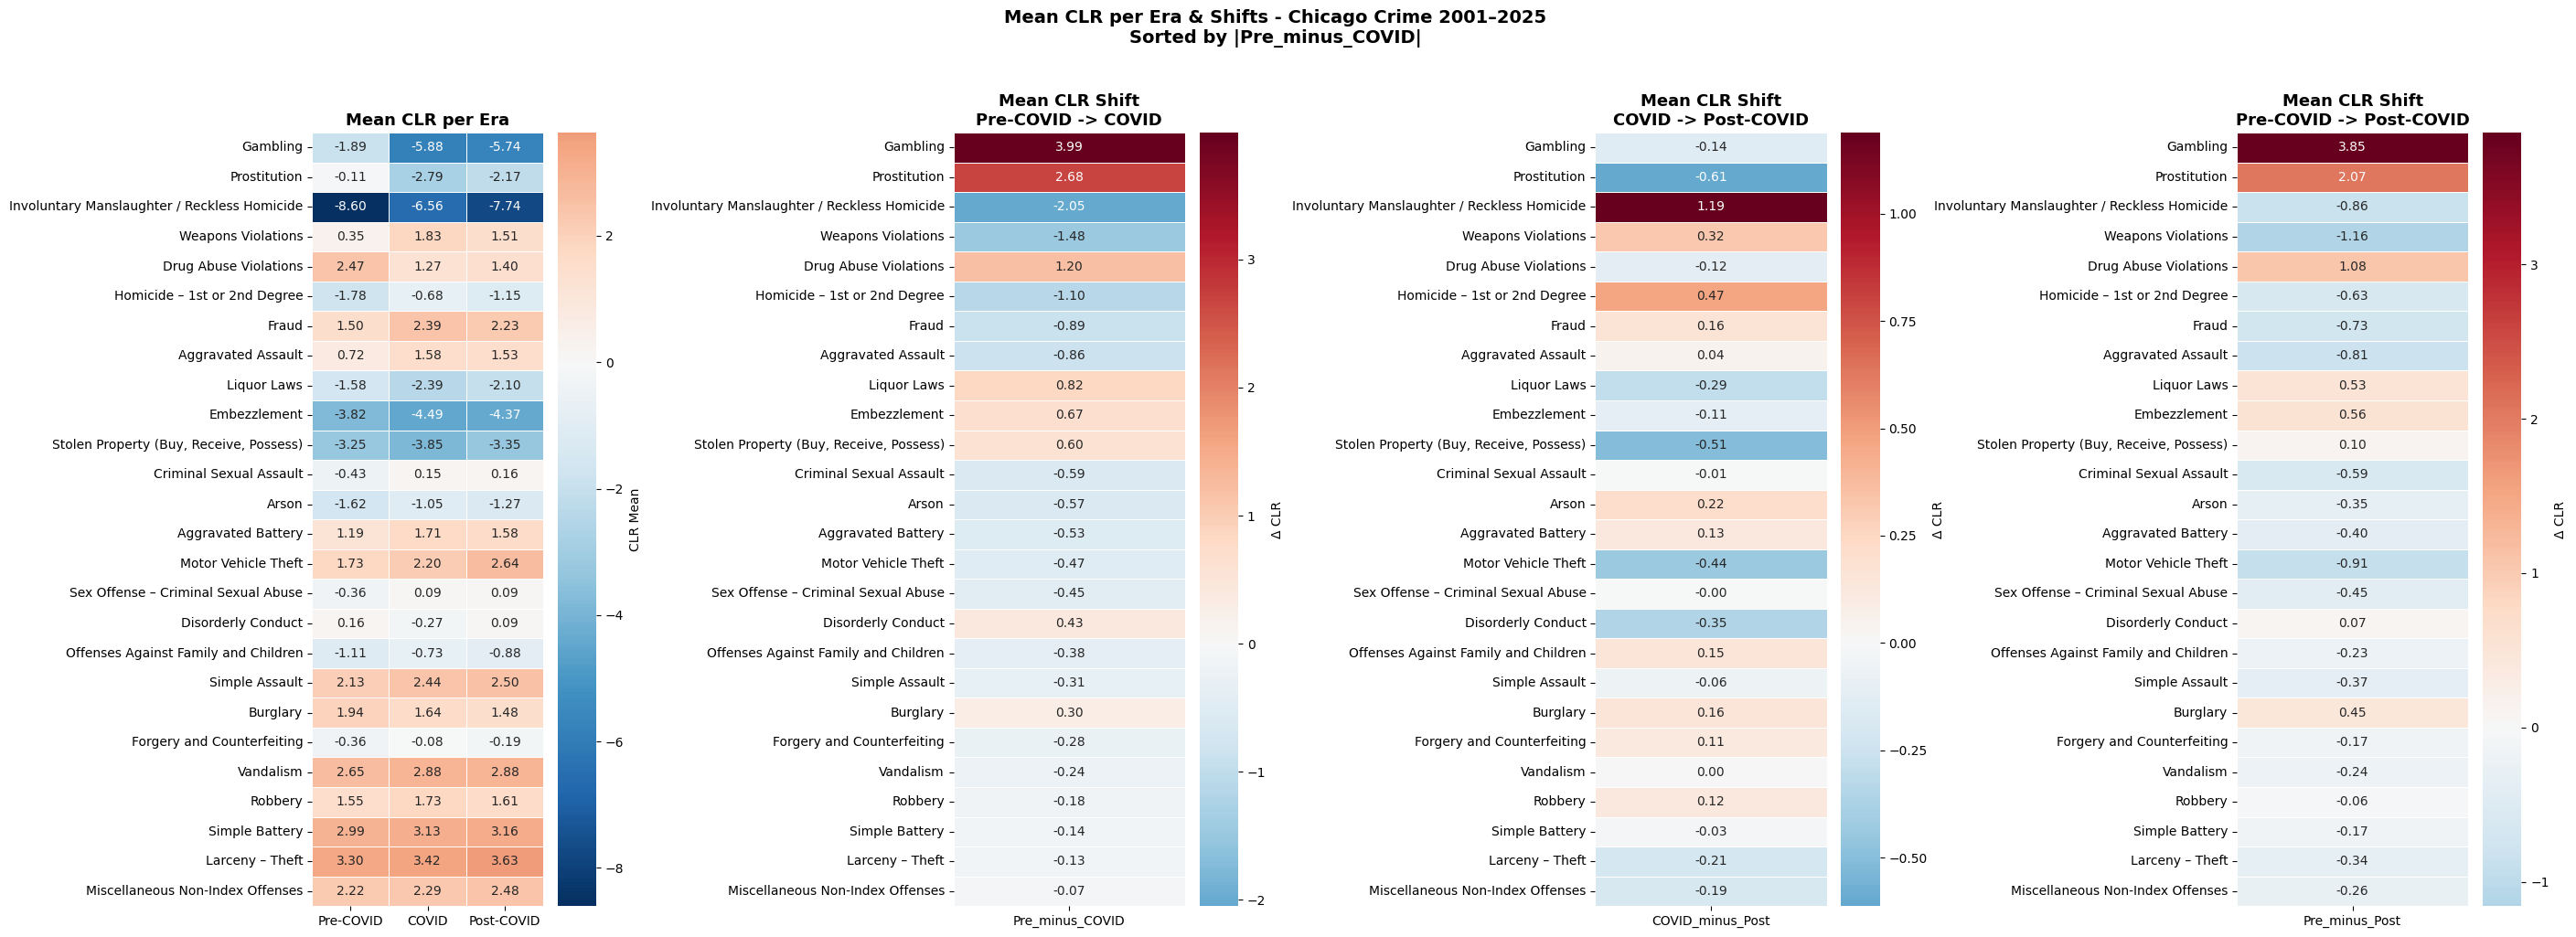

In [21]:
# Plot Mean ERA Shift
clr.plot_mean_era_heatmaps(eras_stat)

## Visualize the Volatility CLR Shift Heatmap

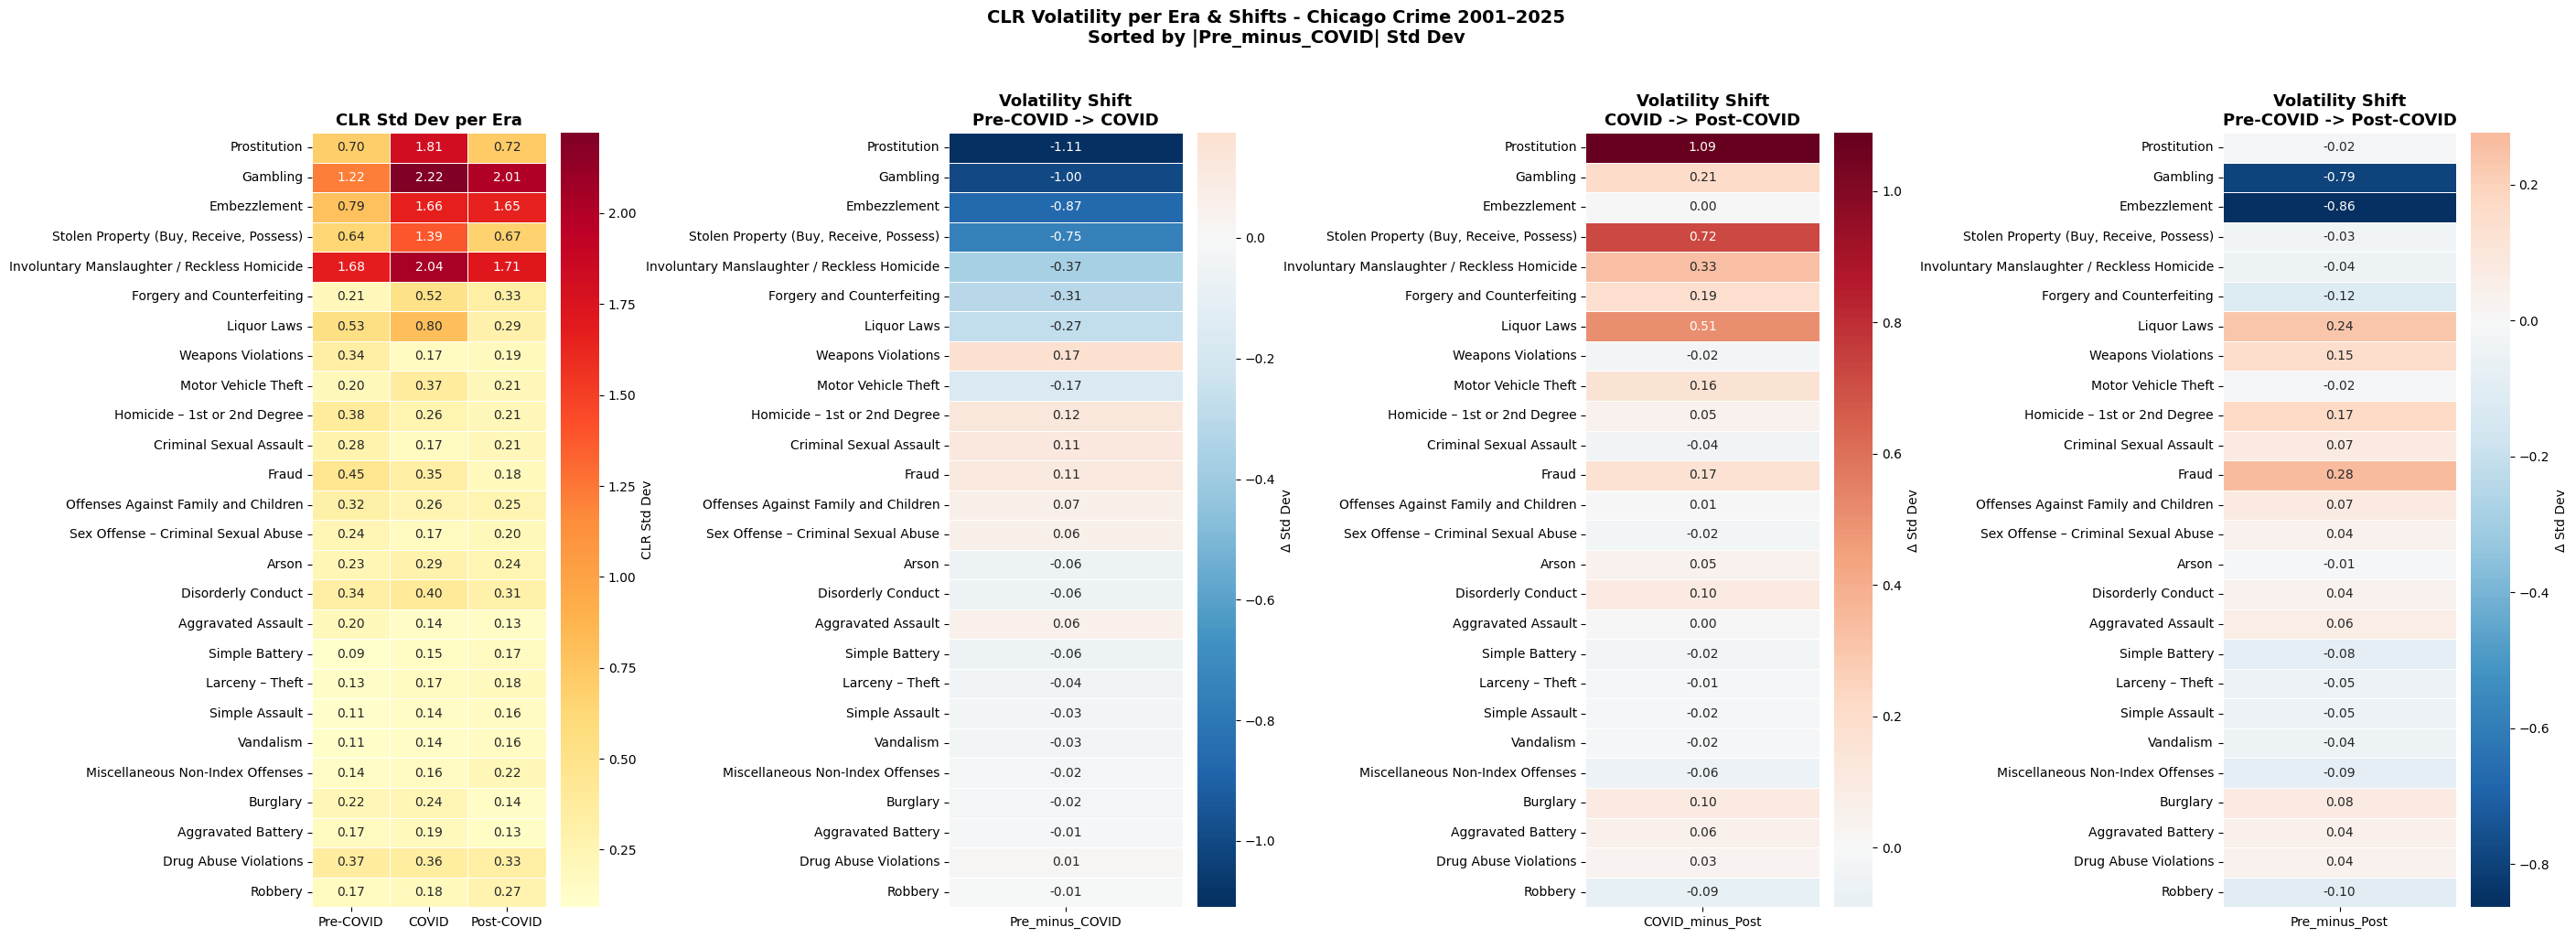

In [22]:
# Plot Volatility Heatmap
clr.plot_std_era_heatmaps(eras_stat)

## Stationarity Testing & Block Bootstrap on the CLR series 
The CLR-transformed series spans 300 months (Jan 2001 – Dec 2025) across three structurally distinct eras separated by known administrative breakpoints. Over this period, Chicago crime composition was subject to major policy shifts (gambling legalization, FOSTA-SESTA, CPD consent decree), demographic changes, and a global pandemic, all of which introduced sustained distributional shifts inconsistent with stationarity. Non-stationarity is therefore theoretically expected and consistent with the structural break detection framework adopted in this analysis. We will still conduct the test to determine whether the CLR-transformed series appears stationary or non-stationary.

**Note:**
>Standard ADF and KPSS tests assume no structural breaks and independent observations. Given the known breakpoints at months 230 (Feb 2020) and 264 (Dec 2022), compositional constraint across K=26 series, and structural zeros in sparse categories, results should be interpreted as indicative rather than definitive. Conflicting results between ADF and KPSS will be reported transparently.

### Step 6a: Stationarity Testing

In [23]:
# Reconstruct clr_df from clr_era
clr_df = pd.concat([
    clr_era['pre_covid'],
    clr_era['covid'],
    clr_era['post_covid']
])

print("clr_df shape:", clr_df.shape)
print("Raw Counts with Filled Data shape:", fill_results['filled_df'].shape)
print("First 3 index:", clr_df.index[:3].tolist())
print("Last  3 index:", clr_df.index[-3:].tolist())

clr_df shape: (304, 26)
Raw Counts with Filled Data shape: (7904, 5)
First 3 index: [Timestamp('2001-01-01 00:00:00'), Timestamp('2001-02-01 00:00:00'), Timestamp('2001-03-01 00:00:00')]
Last  3 index: [Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00'), Timestamp('2026-04-01 00:00:00')]


In [24]:
# Stationarity - CLR
sts_df = clr.run_stationarity_analysis(clr_df, fill_results['filled_df'], era_boundaries=era_boundaries, sparse_threshold=0.05, verbose=True)

STATIONARITY ANALYSIS:    26 Categories     |     2 Sparse Excluded
Total sparse : 2 categories
Total dense  : 24 categories

Sparse category results reported but excluded
from formal stationarity conclusions.
----------------------------------------------------------------------
  Gambling                                          : 9.2%  zeros:  ⚠️
  Involuntary Manslaughter / Reckless Homicide      : 76.6% zeros:  ⚠️
----------------------------------------------------------------------

CONCLUSION COUNTS - ADF + KPSS (dense only):
adf_kpss
Non-Stationary    24

CONCLUSION COUNTS - Zivot-Andrews 'ct' primary (dense only):
za_conclusion
Non-Stationary (ZA)    23
Stationary (ZA)         1

STEP 6a-iv: AGREEMENT - ADF + KPSS vs ZIVOT - ANDREWS (dense only)
agreement
Agree - Non-Stationary    23
Disagree                   1

TREND-SENSITIVE CATEGORIES (break date divergence > 12 months)
Primary model: 'ct'  |  Secondary model: 'c'
                                    Break 'ct' Break 'c' 

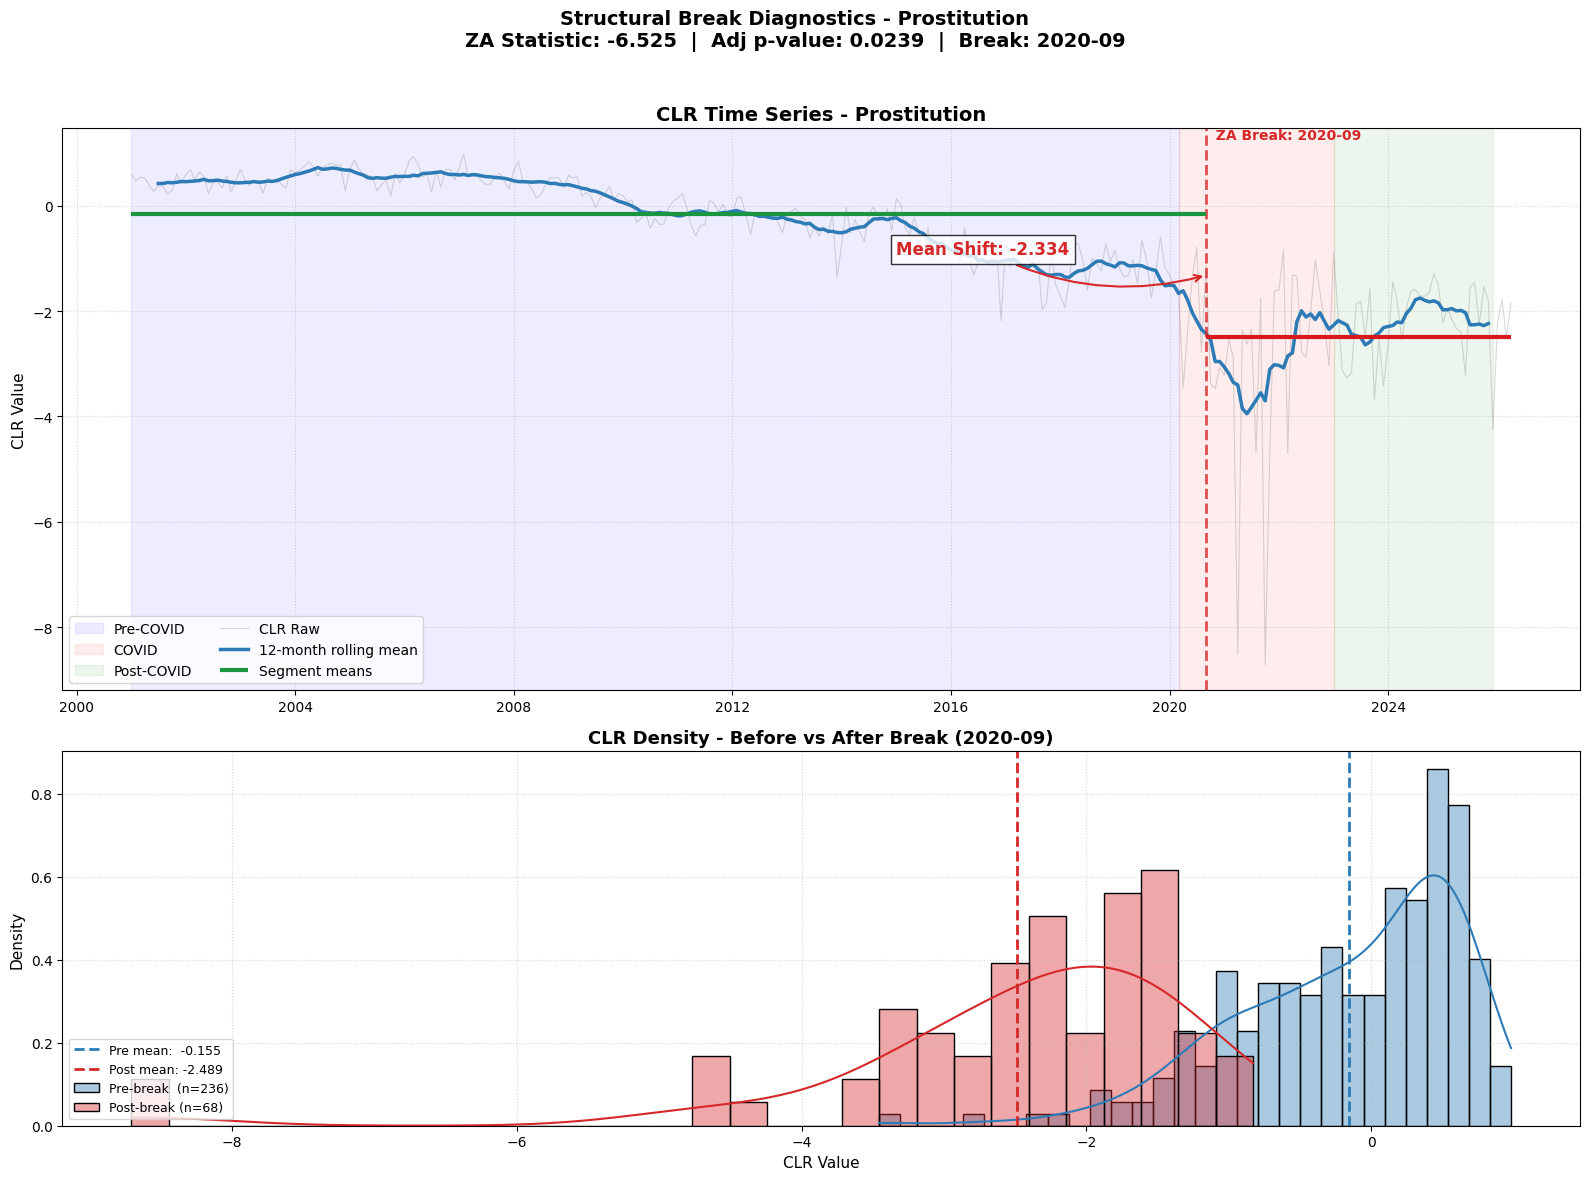

STRUCTURAL BREAK ANALYSIS - Prostitution
Break point : 2020-09
ZA statistic: -6.524525
za_p_adj    : 0.023930  (below α=0.05 ✅)
Conclusion  : Stationary around break

SEGMENT STATISTICS:
            count    mean     std     min     max
Pre-Break   236.0 -0.1551  0.7721 -3.4562  0.9794
Post-Break   68.0 -2.4894  1.3914 -8.7039 -0.8305

Mean shift at break : -2.3343
Pre-break  std      : 0.7721
Post-break std      : 1.3914

Note: Post-break segment (n=68) spans two administrative eras:
  COVID era      : 28   months (2020-03 - 2022-12)
  Post-COVID era : 40   months (2023-01 - 2026-04)
  ZA break does not align with the administrative era boundary.


In [25]:
# Initialize vales
category = 'Prostitution'
windown  = 12
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Era
era_config = {
    'Pre-COVID' : ('2001-01-01', '2020-03-01', 'blue'),
    'COVID'     : ('2020-03-01', '2023-01-01', 'red'),
    'Post-COVID': ('2023-01-01', '2025-12-01', 'green'),
}
# Plot
clr.plot_structural_break(clr_df, category, za_date,
                           era_config, window=windown,
                           za_stat=za_stat,
                           za_p_adj=za_p_adj,
                           era_boundaries = era_boundaries,
                           save_path=f"{image_path}Prostitution_",
                           verbose=True)

The CLR density plot for Prostitution shows two completely separated distributions before and after the September 2020 structural break. The pre-break distribution (n=236) is centered at −0.155 with a standard deviation of 0.772, reflecting a small but stable compositional share of Chicago's crime profile. The post-break distribution (n=68) is centered at −2.489 with a standard deviation of 1.391, a mean shift of −2.334 CLR units, and an 80% increase in volatility. The post-break distribution never recovers above −0.831, confirming that Prostitution's compositional share did not return to pre-pandemic levels. Despite the statistical significance of the break (ZA = −6.525, p = 0.024), this shift reflects a collapse in enforcement policy and the lockdown-induced elimination of street activity rather than underlying behavioral change, consistent with its classification as a flagged category excluded from primary inference.

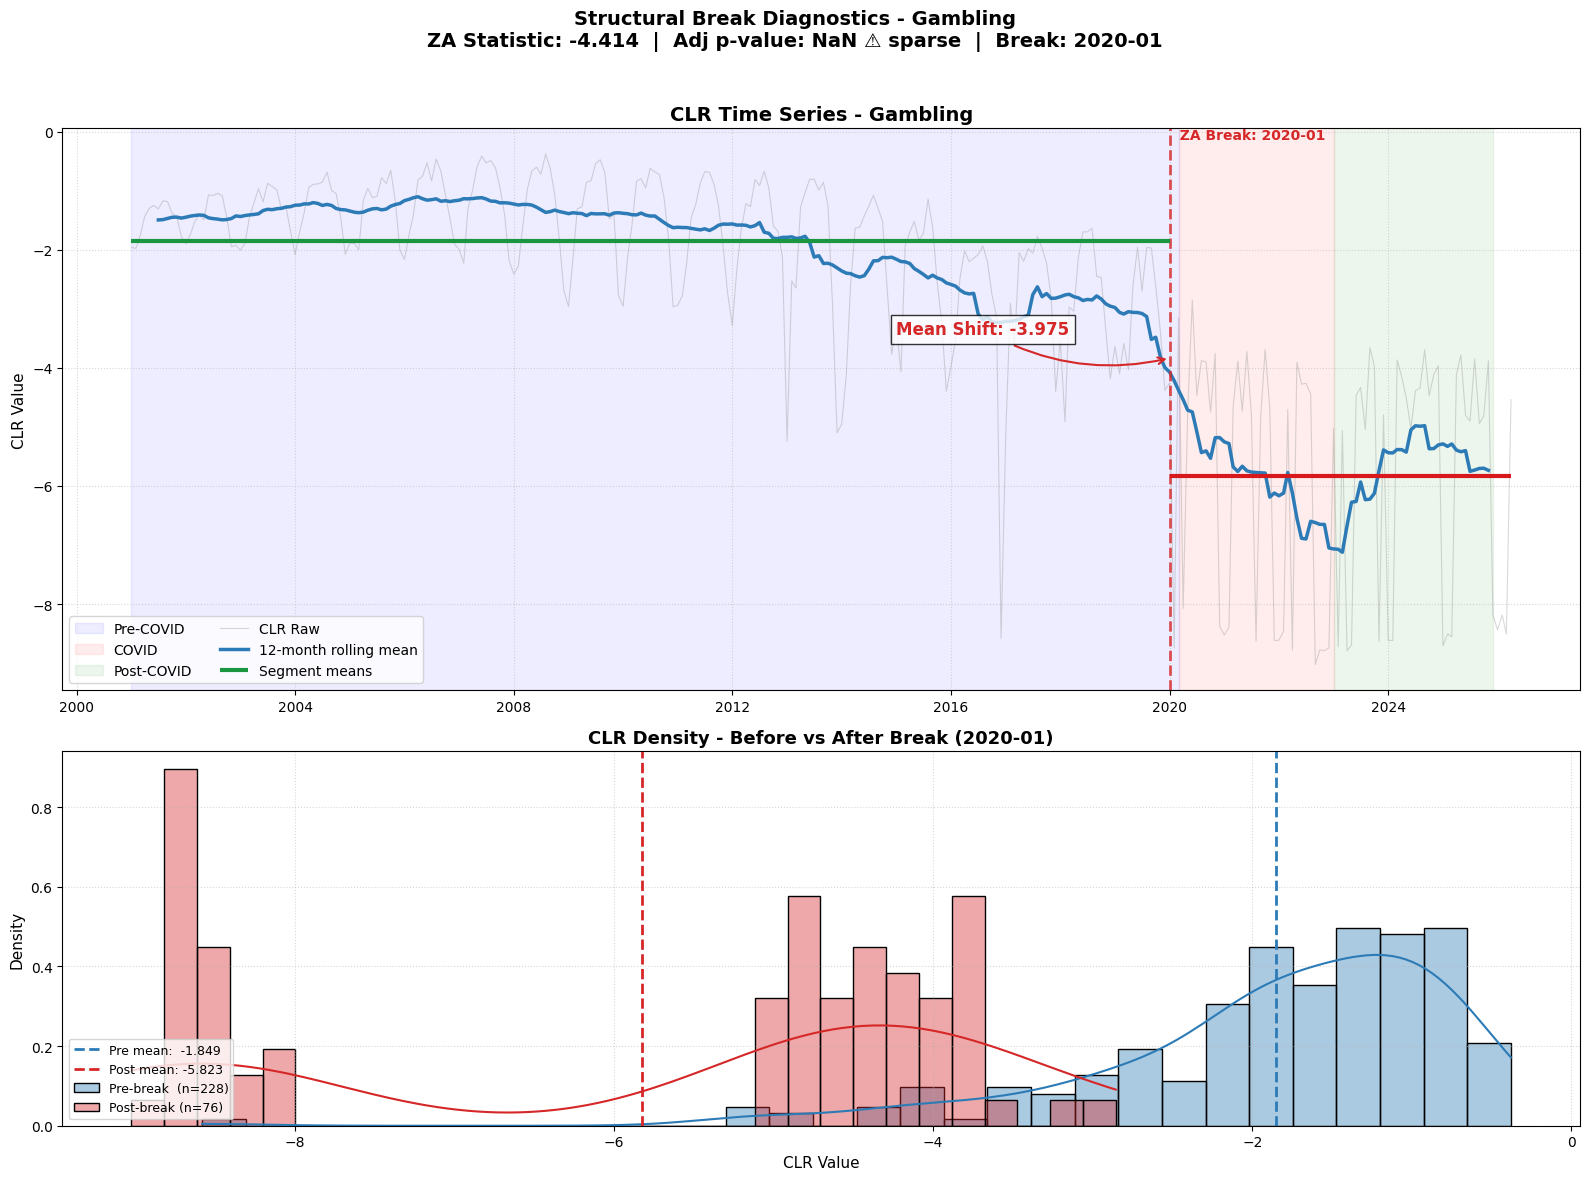

STRUCTURAL BREAK ANALYSIS - Gambling
Break point : 2020-01
ZA statistic: -4.414249
za_p_adj    : nan  (sparse - excluded from FDR) ⚠️
Conclusion  : Unreliable ⚠️ - sparse category

SEGMENT STATISTICS:
            count    mean     std     min     max
Pre-Break   228.0 -1.8487  1.1254 -8.5802 -0.3786
Post-Break   76.0 -5.8234  2.1037 -9.0238 -2.8549

Mean shift at break : -3.9746
Pre-break  std      : 1.1254
Post-break std      : 2.1037

Note: Post-break segment (n=76) spans multiple administrative eras:
  Pre-COVID era  : 2    months (2020-01 - 2020-02)
  COVID era      : 34   months (2020-03 - 2022-12)
  Post-COVID era : 40   months (2023-01 - 2026-04)
  ZA break does not align with the administrative era boundary.


In [26]:
# Initialize vales
category = 'Gambling'
windown  = 12
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Era
era_config = {
    'Pre-COVID' : ('2001-01-01', '2020-03-01', 'blue'),
    'COVID'     : ('2020-03-01', '2023-01-01', 'red'),
    'Post-COVID': ('2023-01-01', '2025-12-01', 'green'),
}

# Plot
clr.plot_structural_break(clr_df, category, za_date,
                           era_config, window=windown,
                           za_stat=za_stat,
                           za_p_adj=za_p_adj,
                           era_boundaries = era_boundaries,
                           save_path=f"{image_path}Gambling_",
                           verbose=True)

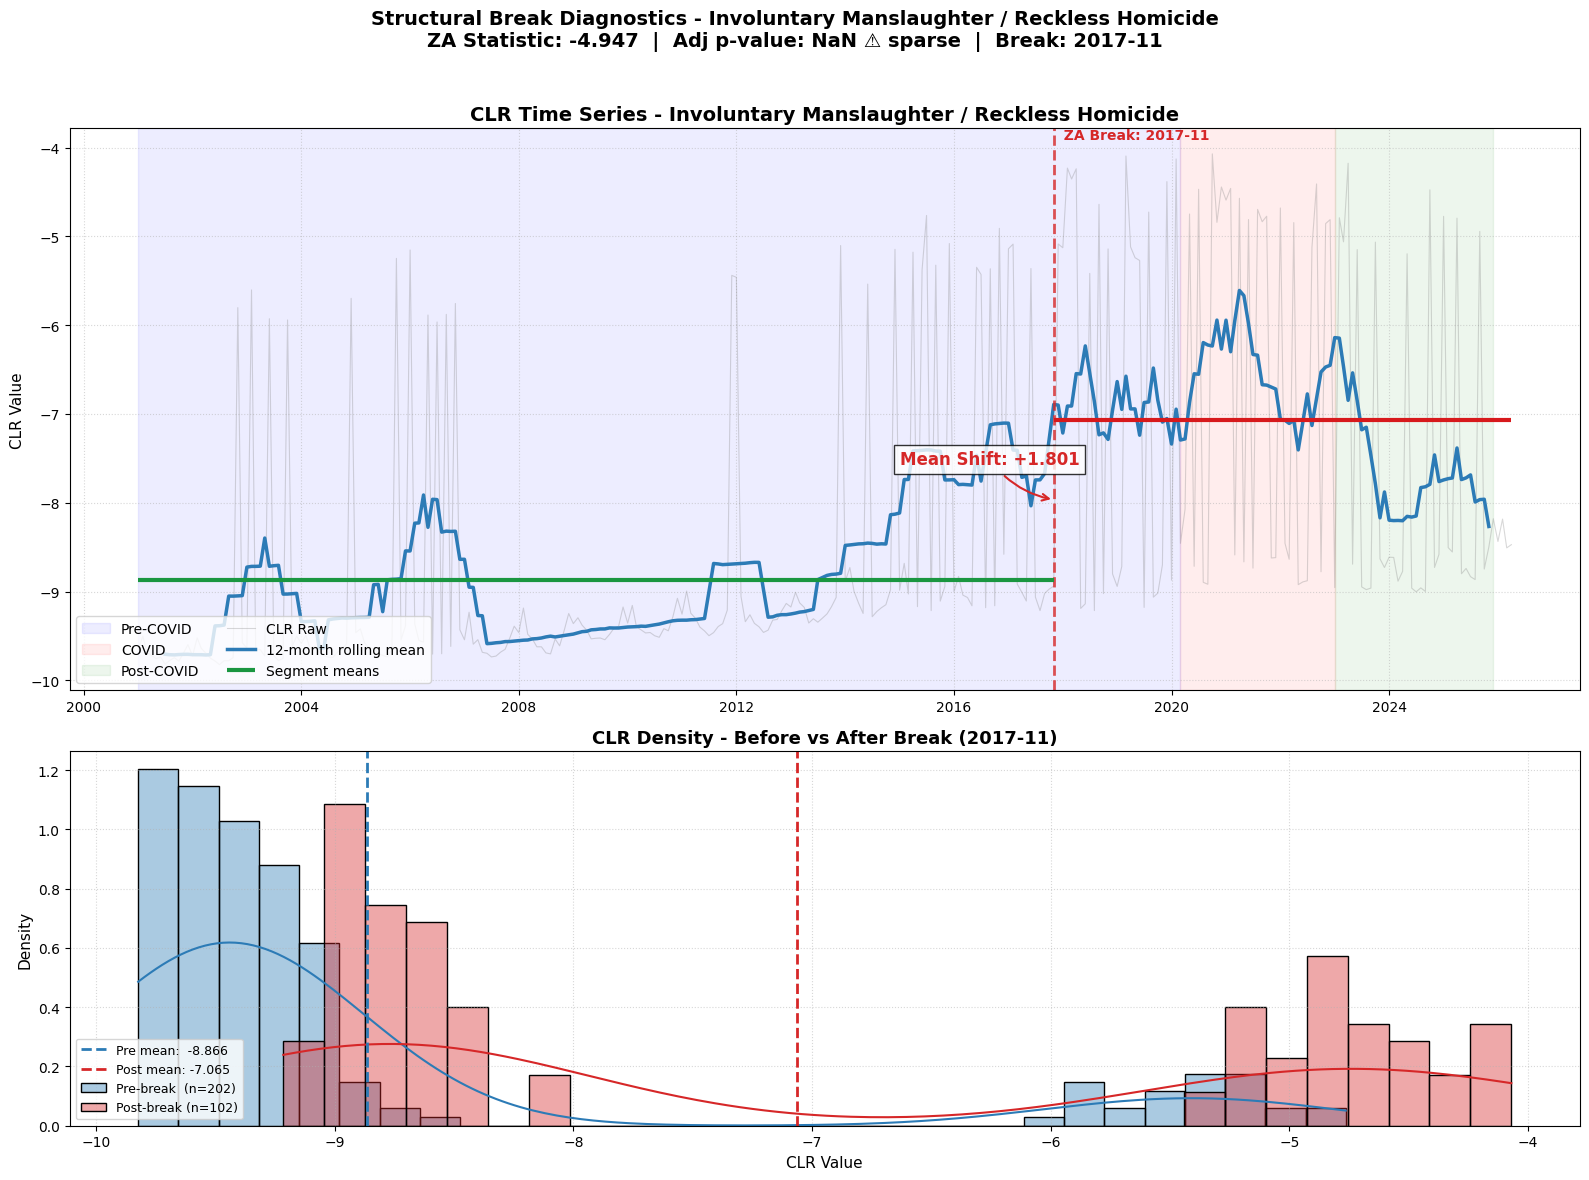

STRUCTURAL BREAK ANALYSIS - Involuntary Manslaughter / Reckless Homicide
Break point : 2017-11
ZA statistic: -4.947056
za_p_adj    : nan  (sparse - excluded from FDR) ⚠️
Conclusion  : Unreliable ⚠️ - sparse category

SEGMENT STATISTICS:
            count    mean     std     min     max
Pre-Break   202.0 -8.8657  1.4107 -9.8230 -4.7635
Post-Break  102.0 -7.0648  2.0197 -9.2148 -4.0699

Mean shift at break : +1.8009
Pre-break  std      : 1.4107
Post-break std      : 2.0197

Note: Post-break segment (n=102) spans multiple administrative eras:
  Pre-COVID era  : 28   months (2017-11 - 2020-02)
  COVID era      : 34   months (2020-03 - 2022-12)
  Post-COVID era : 40   months (2023-01 - 2026-04)
  ZA break does not align with the administrative era boundary.


In [27]:
# Initialize vales
category = 'Involuntary Manslaughter / Reckless Homicide'
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
clr.plot_structural_break(clr_df, category, za_date,
                           era_config, window=windown,
                           za_stat=za_stat,
                           za_p_adj=za_p_adj,
                           era_boundaries = era_boundaries,
                           save_path=f"{image_path}InvManslaughter_",
                           verbose=True)

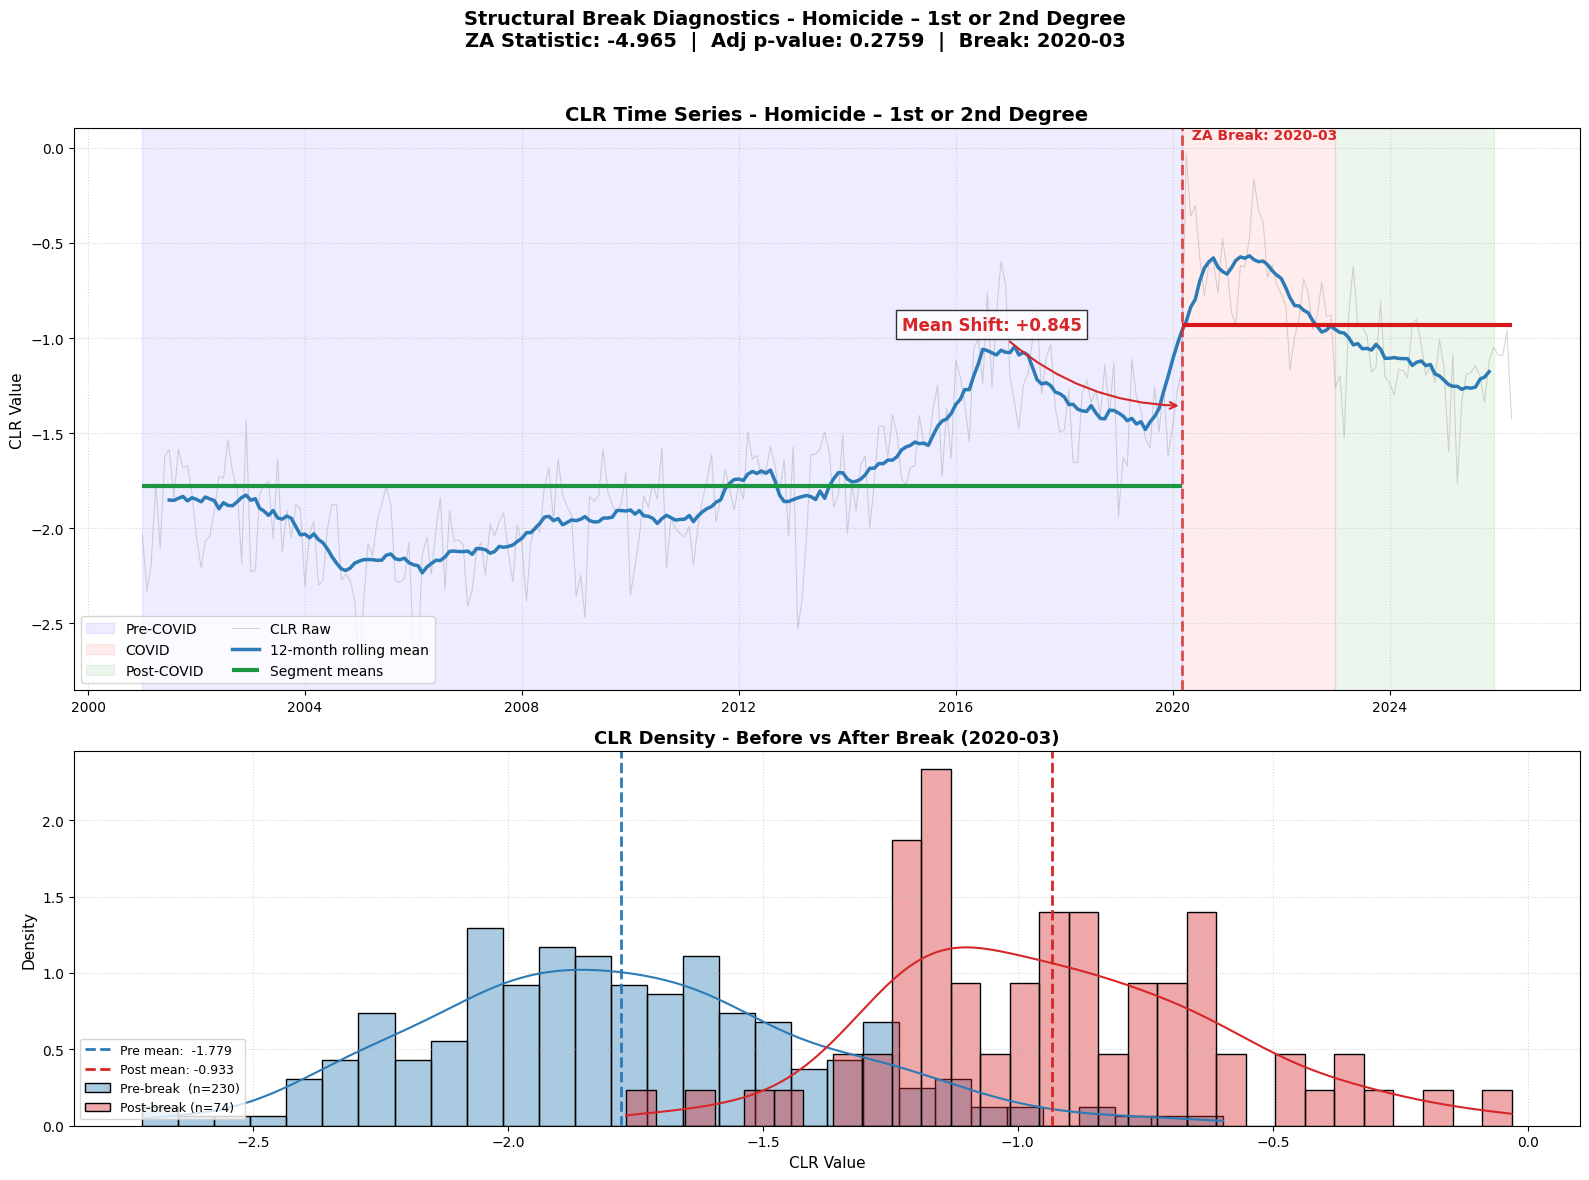

STRUCTURAL BREAK ANALYSIS - Homicide – 1st or 2nd Degree
Break point : 2020-03
ZA statistic: -4.964584
za_p_adj    : 0.275885  (above α=0.05 ❌)
Conclusion  : Non-Stationary (ZA)

SEGMENT STATISTICS:
            count    mean     std     min     max
Pre-Break   230.0 -1.7789  0.3799 -2.7168 -0.5977
Post-Break   74.0 -0.9335  0.3309 -1.7684 -0.0318

Mean shift at break : +0.8455
Pre-break  std      : 0.3799
Post-break std      : 0.3309

Note: Post-break segment (n=74) spans two administrative eras:
  COVID era      : 34   months (2020-03 - 2022-12)
  Post-COVID era : 40   months (2023-01 - 2026-04)
  ZA break does not align with the administrative era boundary.


In [28]:
# Initialize vales
category = 'Homicide – 1st or 2nd Degree'
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
clr.plot_structural_break(clr_df, category, za_date,
                           era_config, window=windown,
                           za_stat=za_stat,
                           za_p_adj=za_p_adj,
                           era_boundaries = era_boundaries,
                           save_path=f"{image_path}InvManslaughter_",
                           verbose=True)
	

### Step 6b: Block Bootstrap Test

In [29]:
# Bootstrap Comparison of Eras
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide',
    'Gambling',
    'Prostitution'
]

# Pre-COVID vs COVID
bootstrap_pc = clr.run_era_comparison(
    chosen_clr,
    clr_era['pre_covid'],
    clr_era['covid'],
    label1      = 'Pre-COVID',
    label2      = 'COVID',
    sparse_cats = sparse_cats,
    verbose     = True,
    seed        = _RANDOM_STATE
)


BLOCK BOOTSTRAP REPORT: Pre-COVID vs COVID
Settings: Block Size=6 | Iterations=10,000 | Effect=Hedges' g | Correction=BH-FDR
Samples:  Pre-COVID (n=230) vs COVID (n=34)
Sign note: hedges_g = mean(era2) - mean(era1). hedges_g_clr = -hedges_g, matching CLR table convention.

CONFIRMED CATEGORIES (dense ✅)
                                         delta_mean  hedges_g  hedges_g_clr  p_bootstrap   p_adj  mean_sig
crime                                                                                                     
Weapons Violations                           1.4763    4.5189       -4.5189       0.0000  0.0000      True
Aggravated Assault                           0.8558    4.5077       -4.5077       0.0000  0.0000      True
Drug Abuse Violations                       -1.2014   -3.2567        3.2567       0.0000  0.0000      True
Homicide – 1st or 2nd Degree                 1.0983    2.9836       -2.9836       0.0000  0.0000      True
Aggravated Battery                           0.5254 

/var/folders/pd/1v40ghc962q88xh6592_w0280000gn/T/ipykernel_25456/2500762009.py:9: UserWarning: 
Block bootstrap - block size auto-adjusted:
  Shortest era      : T = 34
  Requested size    : 12
  Effective blocks  : ~2.8  (minimum recommended: 5)
  Adjusted size     : 6
  Effective blocks  : ~5.7
  Interpret results for this comparison cautiously.
  bootstrap_pc = clr.run_era_comparison(


Block bootstrap resampling (block size=6, auto-adjusted from 12 due to COVID era T=34; 10,000 iterations; BH-FDR correction) across 23 dense categories reveals that 22 of 23 confirmed categories show statistically significant distributional shifts between the pre-COVID and COVID eras. Effect sizes are large to extreme across all significant categories (|g| > 0.71), with Weapons Violations (g = -4.52), Aggravated Assault (g = -4.51), and Drug Abuse Violations (g = +3.26) showing the largest shifts. Shift directions are fully consistent with the CLR mean difference analysis. Miscellaneous Non-Index Offenses is the sole confirmed category failing to reach significance (p_adj=0.089, g=0.51). Three sparse categories, Prostitution, Gambling, and Involuntary Manslaughter, are excluded from BH-FDR correction and formal inference.

In [30]:
# COVID vs Post-COVID
bootstrap_cp = clr.run_era_comparison(
    chosen_clr,
    clr_era['covid'],
    clr_era['post_covid'],
    label1      = 'COVID',
    label2      = 'Post-COVID',
    sparse_cats = sparse_cats,
    verbose     = True,
    seed        = _RANDOM_STATE
)

/var/folders/pd/1v40ghc962q88xh6592_w0280000gn/T/ipykernel_25456/2694276128.py:2: UserWarning: 
Block bootstrap - block size auto-adjusted:
  Shortest era      : T = 34
  Requested size    : 12
  Effective blocks  : ~2.8  (minimum recommended: 5)
  Adjusted size     : 6
  Effective blocks  : ~5.7
  Interpret results for this comparison cautiously.
  bootstrap_cp = clr.run_era_comparison(



BLOCK BOOTSTRAP REPORT: COVID vs Post-COVID
Settings: Block Size=6 | Iterations=10,000 | Effect=Hedges' g | Correction=BH-FDR
Samples:  COVID (n=34) vs Post-COVID (n=40)
Sign note: hedges_g = mean(era2) - mean(era1). hedges_g_clr = -hedges_g, matching CLR table convention.

CONFIRMED CATEGORIES (dense ✅)
                                         delta_mean  hedges_g  hedges_g_clr  p_bootstrap   p_adj  mean_sig
crime                                                                                                     
Homicide – 1st or 2nd Degree                -0.4677   -1.9702        1.9702       0.0009  0.0207      True
Weapons Violations                          -0.3195   -1.7515        1.7515       0.0029  0.0334      True
Motor Vehicle Theft                          0.4394    1.4756       -1.4756       0.0159  0.0805     False
Larceny – Theft                              0.2072    1.1645       -1.1645       0.0175  0.0805     False
Disorderly Conduct                           0.3539

Bootstrap resampling across the COVID-to-Post-COVID transition (block size=6; BH-FDR corrected) reveals that only 2 of 23 confirmed categories showed statistically significant distributional shifts: Homicide (g=+1.97, p=0.021) and Weapons Violations (g=+1.75, p=0.033), both showing partial compositional reversion; basically, the categories are returning toward their usual share of total crime after being disrupted, but only partially so far. The remaining 21 confirmed categories showed no significant change, indicating that the COVID-era distributional shift persisted largely unchanged into the post-COVID period. This near-total stabilization contrasts sharply with the 22 of 23 significant shifts detected in the pre-COVID-to-COVID transition, confirming that COVID represented the dominant structural break rather than the post-COVID recovery period.

In [31]:
# Pre-COVID vs Post-COVID
bootstrap_pp = clr.run_era_comparison(
    chosen_clr,
    clr_era['pre_covid'],
    clr_era['post_covid'],
    label1      = 'Pre-COVID',
    label2      = 'Post-COVID',
    sparse_cats = sparse_cats,
    verbose     = True,
    seed        = _RANDOM_STATE
)

/var/folders/pd/1v40ghc962q88xh6592_w0280000gn/T/ipykernel_25456/3524164972.py:2: UserWarning: 
Block bootstrap - block size auto-adjusted:
  Shortest era      : T = 40
  Requested size    : 12
  Effective blocks  : ~3.3  (minimum recommended: 5)
  Adjusted size     : 8
  Effective blocks  : ~5.0
  Interpret results for this comparison cautiously.
  bootstrap_pp = clr.run_era_comparison(



BLOCK BOOTSTRAP REPORT: Pre-COVID vs Post-COVID
Settings: Block Size=8 | Iterations=10,000 | Effect=Hedges' g | Correction=BH-FDR
Samples:  Pre-COVID (n=230) vs Post-COVID (n=40)
Sign note: hedges_g = mean(era2) - mean(era1). hedges_g_clr = -hedges_g, matching CLR table convention.

CONFIRMED CATEGORIES (dense ✅)
                                         delta_mean  hedges_g  hedges_g_clr  p_bootstrap   p_adj  mean_sig
crime                                                                                                     
Motor Vehicle Theft                          0.9086    4.5706       -4.5706       0.0000  0.0000      True
Aggravated Assault                           0.8115    4.3086       -4.3086       0.0000  0.0000      True
Weapons Violations                           1.1567    3.5510       -3.5510       0.0000  0.0000      True
Simple Assault                               0.3692    3.1891       -3.1891       0.0000  0.0000      True
Drug Abuse Violations                     

Bootstrap resampling across the pre-COVID-to-post-COVID transition (block size=8, auto-adjusted from 12 due to post-COVID era T=40; BH-FDR corrected) reveals that 19 of 23 confirmed categories show statistically significant net permanent shifts relative to the pre-pandemic baseline. Motor Vehicle Theft (g=−4.57), Aggravated Assault (g=−4.31), and Weapons Violations (g=−3.55) show the largest permanent compositional increases. Drug Abuse Violations (g=+2.95) and Burglary (g=+2.16) show the largest permanent compositional decreases. Four categories, Robbery, Disorderly Conduct, Stolen Property, and Offenses Against Family and Children, are showing no significant net change, indicating their COVID-era shifts were transient and fully reverted post-pandemic. All shift directions are fully consistent with the CLR compositional analysis.

In [36]:
%who dict

aitchison_dic	 clr_dict	 clr_era	 cov_results	 epsilon_result	 epsilon_sweep_result	 era_boundaries	 era_config	 eras_stat	 
fill_results	 gambling_count_dic	 integrity_results	 involuntary_count_dic	 pc1_loading_dict	 pc1_stability_dic	 pc1_stability_unstable_8_dic	 prostitution_count_dic	 titles	 
v	 versions	 


In [34]:
import importlib
importlib.reload(clr)

<module 'era_clr' from '/Users/sir/Desktop/Project/ChicagoCrime/Notebook/../Src/era_clr.py'>

## Covariance Structure Analysis


COVARIANCE STRUCTURE ANALYSIS
COVARIANCE MATRIX VALIDATION
  Pre-COVID      : T=230   cov_raw=(26, 26)  cov_lw=(26, 26)  ✅
  COVID          : T=34    cov_raw=(26, 26)  cov_lw=(26, 26)  ✅
  Post-COVID     : T=40    cov_raw=(26, 26)  cov_lw=(26, 26)  ✅

BOX'S M TEST - EQUALITY OF COVARIANCE MATRICES
  Comparison    : Pre-COVID vs COVID vs Post-COVID
  Groups (k)    : 3
  Variables (K) : 26
  Sample sizes  : Pre-COVID=T230, COVID=T34, Post-COVID=T40
  Permutations  : 10,000  seed=1776

  M statistic   : 3130.9071
  p (permuted)  : 0.0000  ✅ reject H0 - structures differ

  H0: Σ_pre = Σ_covid = Σ_post
  H1: At least one covariance matrix differs

  Note: 3 sparse categories included in matrix, flagged ⚠️:
    Gambling
    Involuntary Manslaughter / Reckless Homicide
    Prostitution

Plotting per-era correlation heatmaps...


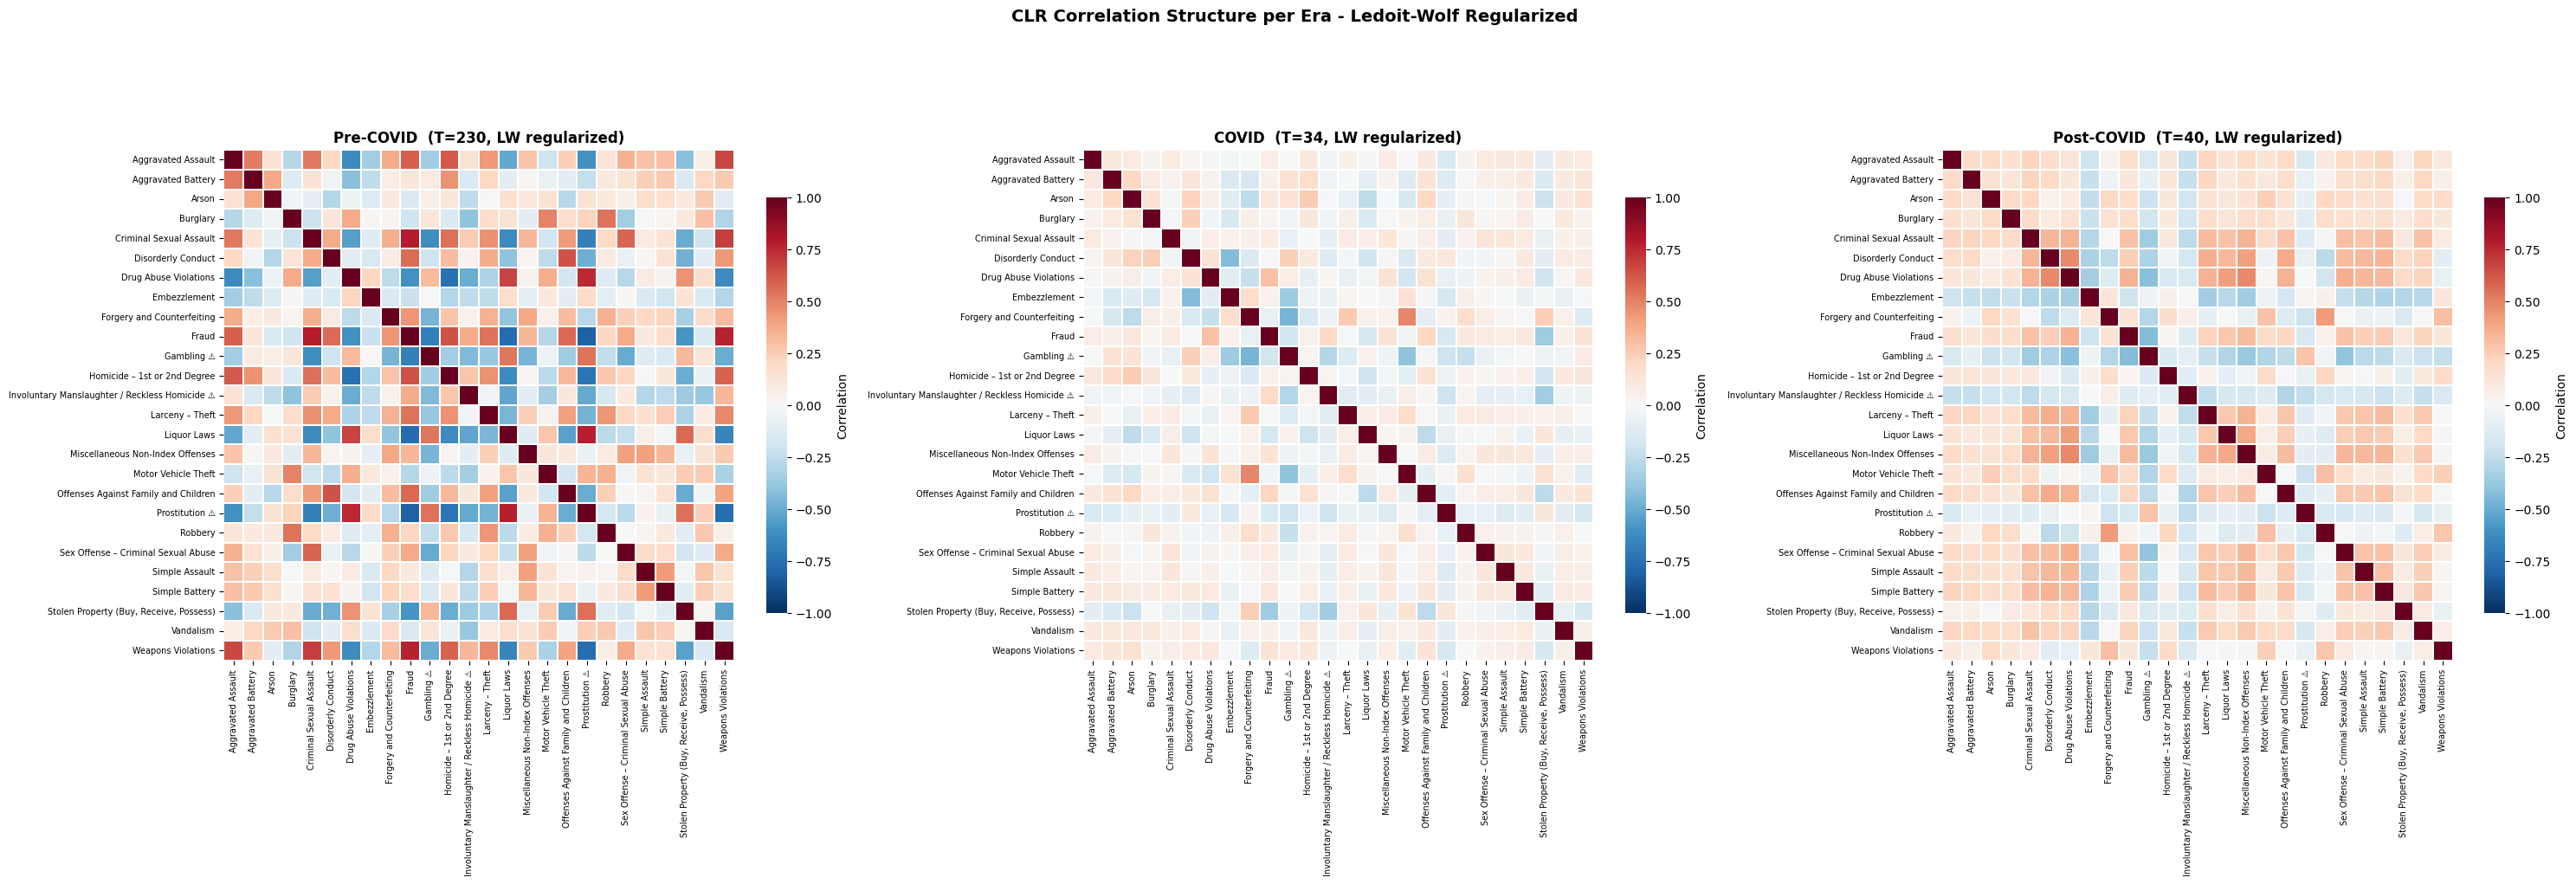

Plotting difference correlation heatmaps...


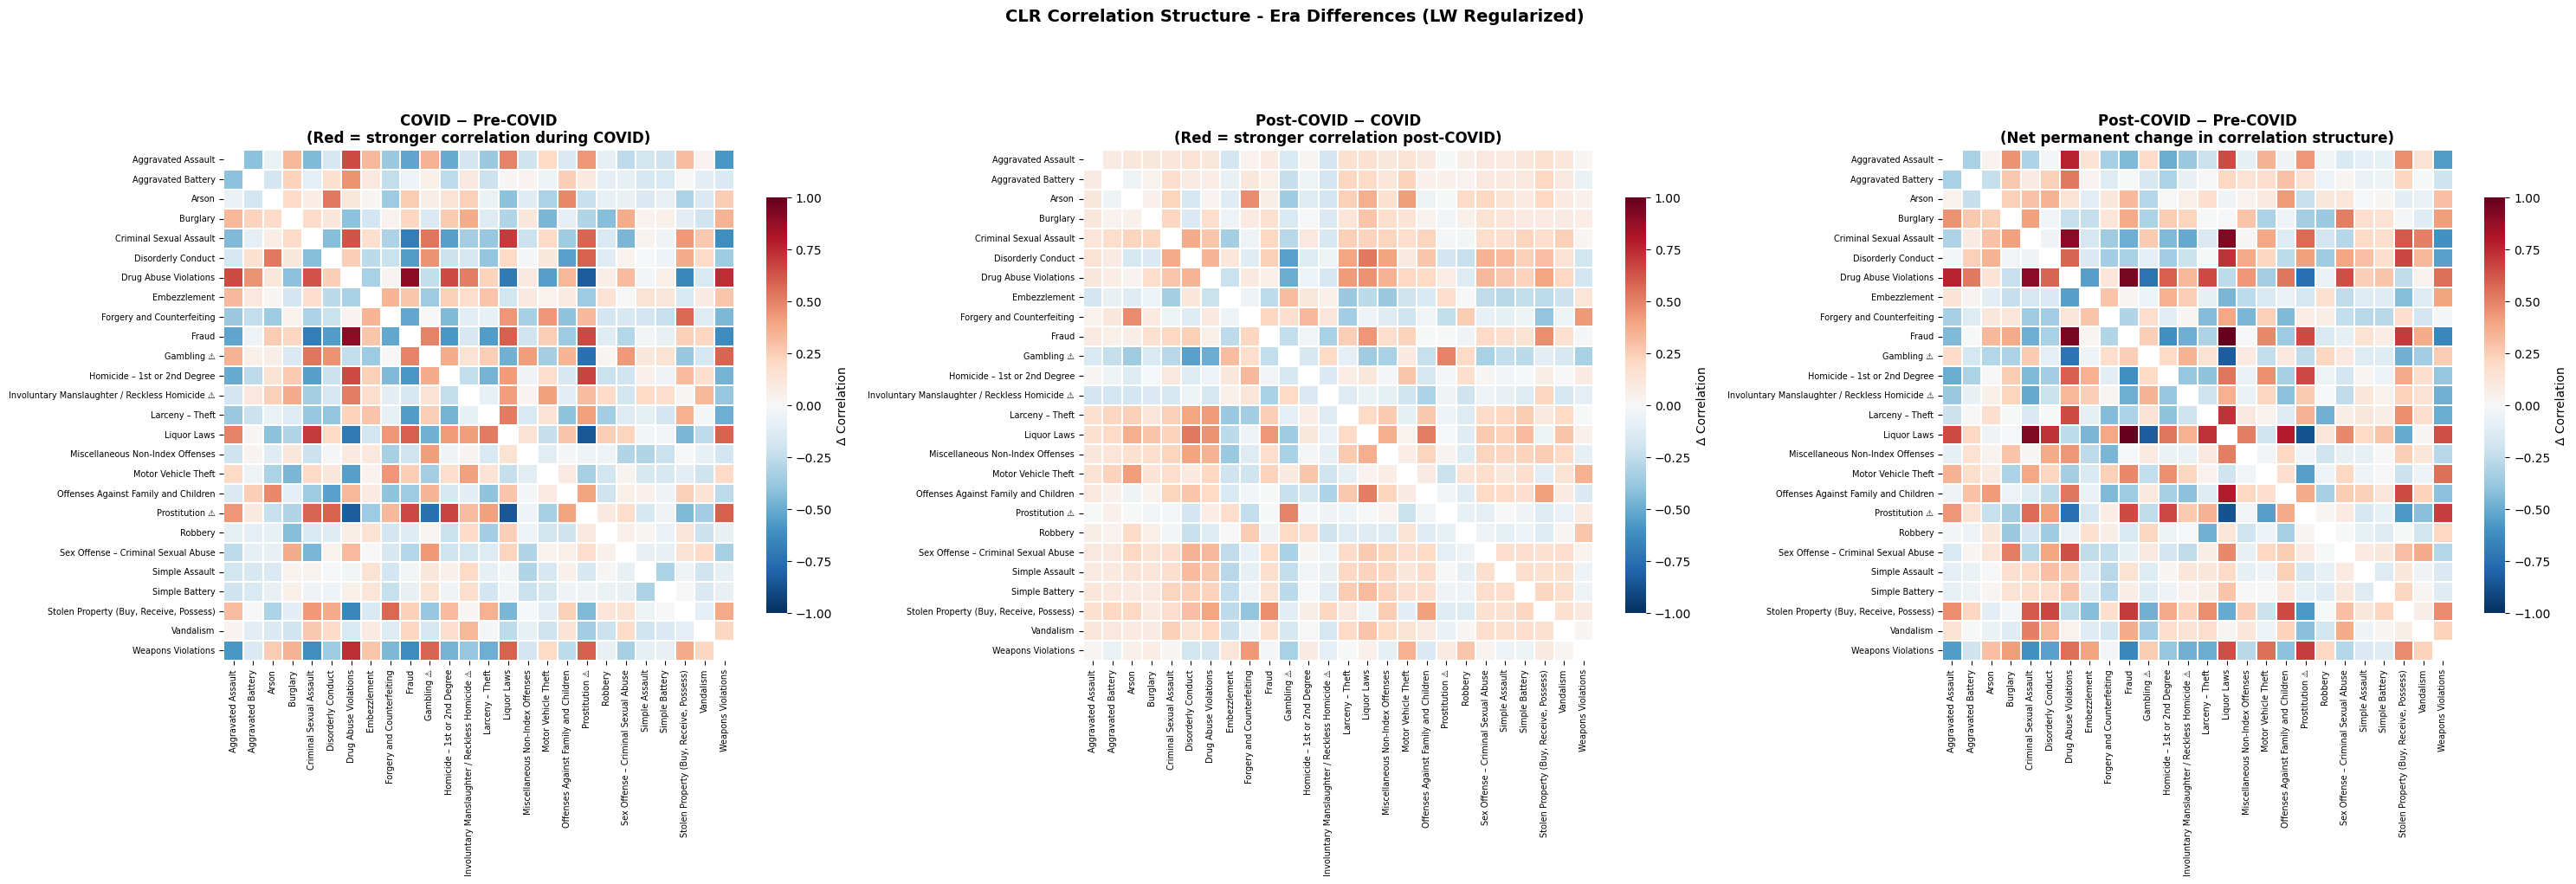


LOG-DETERMINANT COMPARISON - GENERALIZED VARIANCE
  Era                 log|Σ_raw|      log|Σ_lw|      T      T/K  Status
  --------------------------------------------------------------
  Pre-COVID            -129.6863       -78.9252    230     8.85  ✅
  COVID                -126.5965       -35.2641     34     1.31  ⚠️
  Post-COVID           -140.7346       -55.1377     40     1.54  ⚠️

  Δ log|Σ_lw| (LW - used for interpretation):
    COVID − Pre-COVID  : +43.6611
    Post  − COVID      : -19.8736
    Post  − Pre-COVID  : +23.7875

  Interpretation:
    Positive Δ -> crime space EXPANDED (more diverse)
    Negative Δ -> crime space CONTRACTED (more co-moving)

  Note: raw log|Σ| unreliable for COVID/Post-COVID
        (T/K < 5, CLR rank deficiency). Use LW values.

COVARIANCE STRUCTURE ANALYSIS COMPLETE


In [35]:
# Sparse Crime Types
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide',
    'Gambling',
    'Prostitution'
]
# Run test
cov_results = clr.run_covariance_structure_analysis(
    eras_stat       = eras_stat,
    clr_era         = clr_era,
    sparse_cats     = sparse_cats,
    n_permutations  = 10_000,
    seed            = _RANDOM_STATE,
    save_path       = image_path
)